In [1]:
import duckdb
from pathlib import Path

PROJECT_ROOT = Path.cwd()

behavior_path = PROJECT_ROOT / "data" / "raw" / "user_behavior_data.txt"
metadata_path = PROJECT_ROOT / "data" / "raw" / "product_meta_data.txt"

con = duckdb.connect(
    str(PROJECT_ROOT / "jdsearch.duckdb")
)

print("DuckDB connected")
print("Behavior file exists:", behavior_path.exists())
print("Metadata file exists:", metadata_path.exists())

DuckDB connected
Behavior file exists: False
Metadata file exists: False


In [2]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nFiles and folders here:")
for item in Path.cwd().iterdir():
    print(item)

Current working directory:
C:\Users\amodk

Files and folders here:
C:\Users\amodk\.anaconda
C:\Users\amodk\.android
C:\Users\amodk\.cache
C:\Users\amodk\.codex
C:\Users\amodk\.conda
C:\Users\amodk\.condarc
C:\Users\amodk\.continuum
C:\Users\amodk\.copilot
C:\Users\amodk\.fcc
C:\Users\amodk\.gradle
C:\Users\amodk\.idlerc
C:\Users\amodk\.ipynb_checkpoints
C:\Users\amodk\.ipython
C:\Users\amodk\.jupyter
C:\Users\amodk\.matplotlib
C:\Users\amodk\.streamlit
C:\Users\amodk\.VirtualBox
C:\Users\amodk\.vscode
C:\Users\amodk\.vscode-shared
C:\Users\amodk\02_sql_analysis.ipynb
C:\Users\amodk\02_sql_analysis.ipynb.py
C:\Users\amodk\abaqus_2024.gpr
C:\Users\amodk\anaconda3
C:\Users\amodk\AndroidStudioProjects
C:\Users\amodk\AppData
C:\Users\amodk\Application Data
C:\Users\amodk\build
C:\Users\amodk\Contacts
C:\Users\amodk\Cookies
C:\Users\amodk\CrossDevice
C:\Users\amodk\Documents
C:\Users\amodk\Downloads
C:\Users\amodk\Favorites
C:\Users\amodk\get-pip.py
C:\Users\amodk\GIS&RS.ipynb
C:\Users\amodk

In [3]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\amodk\jdsearch-product-analytics"
)

behavior_path = (
    PROJECT_ROOT / "data" / "raw" / "user_behavior_data.txt"
)

metadata_path = (
    PROJECT_ROOT / "data" / "raw" / "product_meta_data.txt"
)

print("Behavior path:", behavior_path)
print("Behavior exists:", behavior_path.exists())

print("Metadata path:", metadata_path)
print("Metadata exists:", metadata_path.exists())

Behavior path: C:\Users\amodk\jdsearch-product-analytics\data\raw\user_behavior_data.txt
Behavior exists: True
Metadata path: C:\Users\amodk\jdsearch-product-analytics\data\raw\product_meta_data.txt
Metadata exists: True


In [4]:
con.execute(f"""
    CREATE OR REPLACE TABLE behavior_raw AS
    SELECT *
    FROM read_csv(
        '{behavior_path.as_posix()}',
        delim = '\t',
        header = true,
        auto_detect = true,
        ignore_errors = true
    );
""")

print("Behavior table created")

Behavior table created


In [5]:
con.sql("""
    SELECT COUNT(*) AS total_search_instances
    FROM behavior_raw
""").df()

,total_search_instances
0,173831


In [6]:
con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_csv(
        '{metadata_path.as_posix()}',
        delim = '\t',
        header = true,
        auto_detect = true,
        ignore_errors = true
    )
""").df()

,column_name,column_type,null,key,default,extra
0,wid,BIGINT,YES,None,None,None
1,name,VARCHAR,YES,None,None,None
2,brand_id,BIGINT,YES,None,None,None
3,brand_name,VARCHAR,YES,None,None,None
4,cate_id_1,BIGINT,YES,None,None,None
5,cate_name_1,VARCHAR,YES,None,None,None
6,cate_id_2,BIGINT,YES,None,None,None
7,cate_name_2,VARCHAR,YES,None,None,None
8,cate_id_3,BIGINT,YES,None,None,None
9,cate_name_3,VARCHAR,YES,None,None,None


In [7]:
con.execute(f"""
    CREATE OR REPLACE TABLE product_metadata AS
    SELECT *
    FROM read_csv(
        '{metadata_path.as_posix()}',
        delim = '\t',
        header = true,
        auto_detect = true,
        ignore_errors = true
    );
""")

print("Product metadata table created")

Product metadata table created


In [8]:
con.sql("""
    DESCRIBE behavior_raw
""").df()

,column_name,column_type,null,key,default,extra
0,query,VARCHAR,YES,None,None,None
1,candidate_wid_list,VARCHAR,YES,None,None,None
2,candidate_label_list,VARCHAR,YES,None,None,None
3,history_qry_list,VARCHAR,YES,None,None,None
4,history_wid_list,VARCHAR,YES,None,None,None
5,history_type_list,VARCHAR,YES,None,None,None
6,history_time_list,VARCHAR,YES,None,None,None


In [10]:
con.sql("""
    SELECT COUNT(*) AS total_search_instances
    FROM behavior_raw
""").df()

,total_search_instances
0,173831


In [11]:
funnel_sql = """
WITH search_outcomes AS (
    SELECT
        candidate_label_list,

        list_contains(
            string_split(candidate_label_list, '_'),
            '1.0'
        ) AS has_click,

        list_contains(
            string_split(candidate_label_list, '_'),
            '2.0'
        ) AS has_cart,

        list_contains(
            string_split(candidate_label_list, '_'),
            '3.0'
        ) AS has_purchase

    FROM behavior_raw
)

SELECT
    COUNT(*) AS total_searches,

    SUM(CASE WHEN has_click THEN 1 ELSE 0 END)
        AS searches_with_click,

    SUM(CASE WHEN has_cart THEN 1 ELSE 0 END)
        AS searches_with_cart,

    SUM(CASE WHEN has_purchase THEN 1 ELSE 0 END)
        AS searches_with_purchase

FROM search_outcomes;
"""

con.sql(funnel_sql).df()

,total_searches,searches_with_click,searches_with_cart,searches_with_purchase
0,173831,126854.0,56775.0,20306.0


In [12]:
con.sql("""
WITH search_outcomes AS (
    SELECT
        list_contains(string_split(candidate_label_list, '_'), '1.0')
            AS has_click,

        list_contains(string_split(candidate_label_list, '_'), '2.0')
            AS has_cart,

        list_contains(string_split(candidate_label_list, '_'), '3.0')
            AS has_purchase

    FROM behavior_raw
),

summary AS (
    SELECT
        COUNT(*) AS total_searches,
        SUM(CASE WHEN has_click THEN 1 ELSE 0 END) AS clicks,
        SUM(CASE WHEN has_cart THEN 1 ELSE 0 END) AS carts,
        SUM(CASE WHEN has_purchase THEN 1 ELSE 0 END) AS purchases
    FROM search_outcomes
)

SELECT
    total_searches,
    clicks,
    carts,
    purchases,

    ROUND(100.0 * clicks / total_searches, 2)
        AS click_search_rate_pct,

    ROUND(100.0 * carts / total_searches, 2)
        AS cart_search_rate_pct,

    ROUND(100.0 * purchases / total_searches, 2)
        AS purchase_search_rate_pct

FROM summary;
""").df()

,total_searches,clicks,carts,purchases,click_search_rate_pct,cart_search_rate_pct,purchase_search_rate_pct
0,173831,126854.0,56775.0,20306.0,72.98,32.66,11.68


In [13]:
con.execute("""
CREATE OR REPLACE TABLE search_funnel_summary AS

WITH search_outcomes AS (
    SELECT
        list_contains(string_split(candidate_label_list, '_'), '1.0')
            AS has_click,

        list_contains(string_split(candidate_label_list, '_'), '2.0')
            AS has_cart,

        list_contains(string_split(candidate_label_list, '_'), '3.0')
            AS has_purchase

    FROM behavior_raw
)

SELECT
    COUNT(*) AS total_searches,

    SUM(CASE WHEN has_click THEN 1 ELSE 0 END)
        AS searches_with_click,

    SUM(CASE WHEN has_cart THEN 1 ELSE 0 END)
        AS searches_with_cart,

    SUM(CASE WHEN has_purchase THEN 1 ELSE 0 END)
        AS searches_with_purchase

FROM search_outcomes;
""")

print("search_funnel_summary table created")

search_funnel_summary table created


In [14]:
con.execute("""
CREATE OR REPLACE TABLE candidate_interactions AS

WITH expanded AS (
    SELECT
        row_number() OVER () AS search_id,
        unnest(string_split(candidate_wid_list, '_'))
            AS product_id,
        unnest(string_split(candidate_label_list, '_'))
            AS interaction_label
    FROM behavior_raw
)

SELECT
    search_id,
    product_id,
    CAST(interaction_label AS DOUBLE) AS interaction_label,

    CASE
        WHEN interaction_label = '0.0' THEN 'no_interaction'
        WHEN interaction_label = '1.0' THEN 'click'
        WHEN interaction_label = '2.0' THEN 'cart'
        WHEN interaction_label = '3.0' THEN 'purchase'
        ELSE 'unknown'
    END AS interaction_type

FROM expanded;
""")

print("candidate_interactions table created")

candidate_interactions table created


In [15]:
con.sql("""
SELECT
    COUNT(*) AS total_candidate_observations,
    COUNT(DISTINCT search_id) AS unique_searches,
    COUNT(DISTINCT product_id) AS unique_products
FROM candidate_interactions;
""").df()

,total_candidate_observations,unique_searches,unique_products
0,15510012,173831,8362535


In [16]:
con.sql("""
SELECT
    interaction_type,
    COUNT(*) AS observations,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        4
    ) AS percentage_of_candidates
FROM candidate_interactions
GROUP BY interaction_type
ORDER BY observations DESC;
""").df()

,interaction_type,observations,percentage_of_candidates
0,no_interaction,15189116,97.9310
1,click,224487,1.4474
2,cart,75573,0.4873
3,purchase,20836,0.1343


In [17]:
con.sql("""
SELECT *
FROM product_metadata
LIMIT 3;
""").df()

,wid,name,brand_id,brand_name,cate_id_1,cate_name_1,cate_id_2,cate_name_2,cate_id_3,cate_name_3,cate_id_4,cate_name_4,shop_id
0,84303384,56009272602574199515329858899060608706386...,81493954,56009272,22259905,44386912,80083037,2787702149701337,13599099,1902766526921156,50485737,4746075788309887,86521100
1,58965086,27823200249212549809550743221450974479927...,15444334,27823200417877058264293359865766,68949654,7722037220300932,58682510,20300932,37322654,9194357497447992,99504987,9194357497447992,1462363
2,33811859,68082682602574199445877660257419536255837...,39479430,68082682,22259905,44386912,80083037,2787702149701337,93252909,20484919753274826921156,42385237,20484912257881342477615,86521100


In [18]:
con.execute("""
CREATE OR REPLACE TABLE product_lookup AS

SELECT
    wid AS product_id,
    brand_id,
    brand_name,
    cate_id_1,
    cate_name_1,
    cate_id_2,
    cate_name_2,
    cate_id_3,
    cate_name_3,
    cate_id_4,
    cate_name_4,
    shop_id

FROM product_metadata;
""")

print("product_lookup table created")

product_lookup table created


In [19]:
con.execute("""
CREATE OR REPLACE TABLE enriched_interactions AS

SELECT
    ci.search_id,
    ci.product_id,
    ci.interaction_label,
    ci.interaction_type,

    pl.brand_id,
    pl.brand_name,
    pl.cate_id_1,
    pl.cate_name_1,
    pl.cate_id_2,
    pl.cate_name_2,
    pl.cate_id_3,
    pl.cate_name_3,
    pl.cate_id_4,
    pl.cate_name_4,
    pl.shop_id

FROM candidate_interactions ci

LEFT JOIN product_lookup pl
    ON ci.product_id = pl.product_id;
""")

print("enriched_interactions table created")

enriched_interactions table created


In [20]:
con.sql("""
SELECT
    COUNT(*) AS total_candidate_rows,

    COUNT(product_id) AS rows_with_product_id,

    COUNT(cate_id_1) AS rows_with_category,

    ROUND(
        100.0 * COUNT(cate_id_1) / COUNT(*),
        2
    ) AS category_coverage_pct

FROM enriched_interactions;
""").df()

,total_candidate_rows,rows_with_product_id,rows_with_category,category_coverage_pct
0,15510012,15510012,15439674,99.55


In [21]:
con.sql("""
SELECT
    COALESCE(cate_name_1, 'Unknown') AS category,

    COUNT(*) AS candidate_exposures,

    SUM(CASE WHEN interaction_type = 'click'
             THEN 1 ELSE 0 END) AS clicks,

    SUM(CASE WHEN interaction_type = 'cart'
             THEN 1 ELSE 0 END) AS carts,

    SUM(CASE WHEN interaction_type = 'purchase'
             THEN 1 ELSE 0 END) AS purchases,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'click'
                 THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS candidate_ctr_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'cart'
                 THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS candidate_cart_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'purchase'
                 THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS candidate_purchase_rate_pct

FROM enriched_interactions

GROUP BY category

HAVING COUNT(*) >= 1000

ORDER BY candidate_ctr_pct DESC;
""").df()

,category,candidate_exposures,clicks,carts,purchases,candidate_ctr_pct,candidate_cart_rate_pct,candidate_purchase_rate_pct
0,13597567,2978,78.0,16.0,1.0,2.619,0.537,0.034
1,1763558,1041,24.0,13.0,1.0,2.305,1.249,0.096
2,36941055,228473,4361.0,1389.0,139.0,1.909,0.608,0.061
3,35242963,356564,6712.0,1544.0,163.0,1.882,0.433,0.046
4,2566259413598299338579564374850996934502,24338,457.0,252.0,67.0,1.878,1.035,0.275
5,52668508,12714,237.0,36.0,3.0,1.864,0.283,0.024
6,7722037220300932,953096,17601.0,2903.0,780.0,1.847,0.305,0.082
7,6957538133653732,167684,3092.0,726.0,62.0,1.844,0.433,0.037
8,4338732011476273,814752,14837.0,3511.0,663.0,1.821,0.431,0.081
9,58546307,234278,4215.0,783.0,213.0,1.799,0.334,0.091


In [22]:
category_funnel = con.sql("""
SELECT
    COALESCE(cate_name_1, 'Unknown') AS category,
    COUNT(*) AS candidate_exposures,

    SUM(CASE WHEN interaction_type = 'click'
             THEN 1 ELSE 0 END) AS clicks,

    SUM(CASE WHEN interaction_type = 'cart'
             THEN 1 ELSE 0 END) AS carts,

    SUM(CASE WHEN interaction_type = 'purchase'
             THEN 1 ELSE 0 END) AS purchases,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'click'
                 THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS candidate_ctr_pct

FROM enriched_interactions

GROUP BY category

HAVING COUNT(*) >= 1000

ORDER BY candidate_ctr_pct DESC;
""").df()

category_funnel.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "category_funnel.csv",
    index=False
)

category_funnel.head(10)

,category,candidate_exposures,clicks,carts,purchases,candidate_ctr_pct
0,13597567,2978,78.0,16.0,1.0,2.619
1,1763558,1041,24.0,13.0,1.0,2.305
2,36941055,228473,4361.0,1389.0,139.0,1.909
3,35242963,356564,6712.0,1544.0,163.0,1.882
4,2566259413598299338579564374850996934502,24338,457.0,252.0,67.0,1.878
5,52668508,12714,237.0,36.0,3.0,1.864
6,7722037220300932,953096,17601.0,2903.0,780.0,1.847
7,6957538133653732,167684,3092.0,726.0,62.0,1.844
8,4338732011476273,814752,14837.0,3511.0,663.0,1.821
9,58546307,234278,4215.0,783.0,213.0,1.799


In [23]:
con.execute("""
DROP TABLE IF EXISTS candidate_interactions;
DROP TABLE IF EXISTS enriched_interactions;
""")

print("Incorrect interaction tables removed")

Incorrect interaction tables removed


In [24]:
con.execute("""
CREATE OR REPLACE TABLE candidate_interactions AS

WITH base AS (
    SELECT
        row_number() OVER () AS search_id,
        string_split(candidate_wid_list, '_') AS product_ids,
        string_split(candidate_label_list, '_') AS labels
    FROM behavior_raw
),

expanded AS (
    SELECT
        search_id,
        product_ids[i] AS product_id,
        labels[i] AS interaction_label
    FROM base,
    LATERAL range(
        1,
        LEAST(array_length(product_ids), array_length(labels)) + 1
    ) AS r(i)
)

SELECT
    search_id,
    product_id,
    CAST(interaction_label AS DOUBLE) AS interaction_label,

    CASE
        WHEN interaction_label = '0.0' THEN 'no_interaction'
        WHEN interaction_label = '1.0' THEN 'click'
        WHEN interaction_label = '2.0' THEN 'cart'
        WHEN interaction_label = '3.0' THEN 'purchase'
        ELSE 'unknown'
    END AS interaction_type

FROM expanded;
""")

print("Corrected candidate_interactions table created")

Corrected candidate_interactions table created


In [25]:
con.sql("""
SELECT
    COUNT(*) AS total_candidate_observations,
    COUNT(DISTINCT search_id) AS unique_searches,
    COUNT(DISTINCT product_id) AS unique_products
FROM candidate_interactions;
""").df()

,total_candidate_observations,unique_searches,unique_products
0,15510012,173831,8362535


In [26]:
con.execute("""
CREATE OR REPLACE TABLE enriched_interactions AS

SELECT
    ci.search_id,
    ci.product_id,
    ci.interaction_label,
    ci.interaction_type,

    pm.brand_id,
    pm.brand_name,
    pm.cate_id_1,
    pm.cate_name_1,
    pm.cate_id_2,
    pm.cate_name_2,
    pm.cate_id_3,
    pm.cate_name_3,
    pm.cate_id_4,
    pm.cate_name_4,
    pm.shop_id

FROM candidate_interactions ci

LEFT JOIN product_metadata pm
    ON ci.product_id = pm.wid;
""")

print("Corrected enriched_interactions table created")

Corrected enriched_interactions table created


In [27]:
con.sql("""
SELECT
    COALESCE(cate_name_1, 'Unknown') AS category,

    COUNT(*) AS candidate_observations,

    SUM(CASE WHEN interaction_type = 'click'
             THEN 1 ELSE 0 END) AS clicks,

    SUM(CASE WHEN interaction_type = 'cart'
             THEN 1 ELSE 0 END) AS carts,

    SUM(CASE WHEN interaction_type = 'purchase'
             THEN 1 ELSE 0 END) AS purchases,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'click'
                 THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS candidate_ctr_pct

FROM enriched_interactions

GROUP BY category

HAVING COUNT(*) >= 1000

ORDER BY candidate_ctr_pct DESC;
""").df()

,category,candidate_observations,clicks,carts,purchases,candidate_ctr_pct
0,13597567,2978,78.0,16.0,1.0,2.619
1,1763558,1041,24.0,13.0,1.0,2.305
2,36941055,228473,4361.0,1389.0,139.0,1.909
3,35242963,356564,6712.0,1544.0,163.0,1.882
4,2566259413598299338579564374850996934502,24338,457.0,252.0,67.0,1.878
5,52668508,12714,237.0,36.0,3.0,1.864
6,7722037220300932,953096,17601.0,2903.0,780.0,1.847
7,6957538133653732,167684,3092.0,726.0,62.0,1.844
8,4338732011476273,814752,14837.0,3511.0,663.0,1.821
9,58546307,234278,4215.0,783.0,213.0,1.799


In [28]:
con.sql("""
SELECT
    interaction_type,
    COUNT(*) AS interaction_count
FROM candidate_interactions
GROUP BY interaction_type
ORDER BY interaction_type;
""").df()

,interaction_type,interaction_count
0,cart,75573
1,click,224487
2,no_interaction,15189116
3,purchase,20836


In [29]:
con.sql("""
SELECT
    COUNT(*) AS total_enriched_rows,
    SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END)
        AS total_clicks,
    SUM(CASE WHEN interaction_type = 'cart' THEN 1 ELSE 0 END)
        AS total_carts,
    SUM(CASE WHEN interaction_type = 'purchase' THEN 1 ELSE 0 END)
        AS total_purchases
FROM enriched_interactions;
""").df()

,total_enriched_rows,total_clicks,total_carts,total_purchases
0,15510012,224487.0,75573.0,20836.0


In [30]:
con.sql("""
SELECT
    cate_id_1,
    cate_name_1,
    COUNT(*) AS product_count
FROM product_metadata
GROUP BY cate_id_1, cate_name_1
ORDER BY product_count DESC
LIMIT 20;
""").df()

,cate_id_1,cate_name_1,product_count
0,68949654,7722037220300932,1115235
1,24093831,4338732011476273,915250
2,920973,413810773160222581402210,863801
3,98371044,3153887681590330,780954
4,31606173,9483389095217261,639905
5,56696958,80488822,584085
6,63959387,223100,535597
7,79514364,4875869,493090
8,91302620,163221,446661
9,98719916,5905495980470873,442606


In [31]:
con.sql("""
WITH base AS (
    SELECT
        row_number() OVER () AS search_id,
        array_length(string_split(candidate_wid_list, chr(24))) AS candidate_count,
        array_length(string_split(candidate_label_list, '_')) AS label_count
    FROM behavior_raw
)
SELECT
    COUNT(*) AS total_searches,
    SUM(candidate_count = label_count) AS aligned_searches,
    SUM(candidate_count <> label_count) AS mismatched_searches,
    MIN(candidate_count) AS min_candidates,
    MAX(candidate_count) AS max_candidates,
    AVG(candidate_count) AS avg_candidates
FROM base;
""").df()

,total_searches,aligned_searches,mismatched_searches,min_candidates,max_candidates,avg_candidates
0,173831,487.0,173344.0,1,1,1.0


In [32]:
con.sql("""
SELECT
    candidate_wid_list,
    candidate_label_list,
    length(candidate_wid_list) AS candidate_string_length,
    length(candidate_label_list) AS label_string_length
FROM behavior_raw
LIMIT 10;
""").df()

,candidate_wid_list,candidate_label_list,candidate_string_length,label_string_length
0,36098226_17729172_34921664_68317377_693764_360...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,801,359
1,30857980_44577431_1485384_63372823_19754701_29...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,794,355
2,42155506_90092899_4336287_74203839_39478459_37...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,739,331
3,97234676_89827009_19973201_83859812_22172053_3...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,116,51
4,19711065_83045333_8307571_20337381_11912759_53...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,812,367
5,35220227_55256570_62909652_29254062_3615332_25...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,165,75
6,34165613_22537653_16951981_59080994_20441183_7...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,779,347
7,82948709_41663570_1369970_85676525_7169299_187...,1.0_1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,1000,447
8,53684976_82183280_85796531_4330421_90635725_51...,1.0_1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,1348,607
9,80808907_47048799_6746657_31841033_36057425_62...,1.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0.0_0....,316,143


In [33]:
con.sql("""
SELECT
    candidate_wid_list,
    regexp_extract_all(candidate_wid_list, '[0-9]+') AS extracted_product_ids,
    string_split(candidate_label_list, '_') AS labels
FROM behavior_raw
LIMIT 5;
""").df()

,candidate_wid_list,extracted_product_ids,labels
0,36098226_17729172_34921664_68317377_693764_360...,"[36098226, 17729172, 34921664, 68317377, 69376...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,30857980_44577431_1485384_63372823_19754701_29...,"[30857980, 44577431, 1485384, 63372823, 197547...","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,42155506_90092899_4336287_74203839_39478459_37...,"[42155506, 90092899, 4336287, 74203839, 394784...","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,97234676_89827009_19973201_83859812_22172053_3...,"[97234676, 89827009, 19973201, 83859812, 22172...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,19711065_83045333_8307571_20337381_11912759_53...,"[19711065, 83045333, 8307571, 20337381, 119127...","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [34]:
con.sql("""
WITH base AS (
    SELECT
        row_number() OVER () AS search_id,
        array_length(string_split(candidate_wid_list, '_')) AS candidate_count,
        array_length(string_split(candidate_label_list, '_')) AS label_count
    FROM behavior_raw
)
SELECT
    COUNT(*) AS total_searches,
    SUM(candidate_count = label_count) AS aligned_searches,
    SUM(candidate_count <> label_count) AS mismatched_searches,
    MIN(candidate_count) AS min_candidates,
    MAX(candidate_count) AS max_candidates,
    ROUND(AVG(candidate_count), 2) AS avg_candidates
FROM base;
""").df()

,total_searches,aligned_searches,mismatched_searches,min_candidates,max_candidates,avg_candidates
0,173831,173831.0,0.0,1,200,89.22


In [35]:
con.execute("""
DROP TABLE IF EXISTS enriched_interactions;
DROP TABLE IF EXISTS candidate_interactions;
""")

con.execute("""
CREATE TABLE candidate_interactions AS
WITH base AS (
    SELECT
        row_number() OVER () AS search_id,
        string_split(candidate_wid_list, '_') AS product_ids,
        string_split(candidate_label_list, '_') AS labels
    FROM behavior_raw
),
expanded AS (
    SELECT
        search_id,
        product_ids[i] AS product_id,
        labels[i] AS interaction_label
    FROM base,
    LATERAL range(
        1,
        LEAST(
            array_length(product_ids),
            array_length(labels)
        ) + 1
    ) AS r(i)
)
SELECT
    search_id,
    product_id,
    CASE
        WHEN CAST(interaction_label AS DOUBLE) = 0 THEN 'no_interaction'
        WHEN CAST(interaction_label AS DOUBLE) = 1 THEN 'click'
        WHEN CAST(interaction_label AS DOUBLE) = 2 THEN 'cart'
        WHEN CAST(interaction_label AS DOUBLE) = 3 THEN 'purchase'
        ELSE 'unknown'
    END AS interaction_type
FROM expanded;
""")

In [36]:
con.sql("""
SELECT
    interaction_type,
    COUNT(*) AS interaction_count
FROM candidate_interactions
GROUP BY interaction_type
ORDER BY interaction_type;
""").df()

,interaction_type,interaction_count
0,cart,75573
1,click,224487
2,no_interaction,15189116
3,purchase,20836


In [37]:
con.sql("""
SELECT COUNT(*) AS total_candidate_rows
FROM candidate_interactions;
""").df()

,total_candidate_rows
0,15510012


In [38]:
con.execute("""
DROP TABLE IF EXISTS enriched_interactions;
""")

con.execute("""
CREATE TABLE enriched_interactions AS
SELECT
    ci.search_id,
    ci.product_id,
    ci.interaction_type,
    pm.wid,
    pm.brand_id,
    pm.brand_name,
    pm.cate_id_1,
    pm.cate_name_1,
    pm.cate_id_2,
    pm.cate_name_2,
    pm.cate_id_3,
    pm.cate_name_3,
    pm.cate_id_4,
    pm.cate_name_4,
    pm.shop_id
FROM candidate_interactions ci
LEFT JOIN product_metadata pm
    ON ci.product_id = pm.wid;
""")

In [39]:
con.sql("""
SELECT
    COUNT(*) AS total_candidate_rows,
    COUNT(wid) AS matched_metadata_rows,
    COUNT(*) - COUNT(wid) AS missing_metadata_rows,
    ROUND(
        100.0 * COUNT(wid) / COUNT(*),
        2
    ) AS metadata_match_rate
FROM enriched_interactions;
""").df()

,total_candidate_rows,matched_metadata_rows,missing_metadata_rows,metadata_match_rate
0,15510012,15439674,70338,99.55


In [40]:
con.sql("""
SELECT
    interaction_type,
    COUNT(*) AS interaction_count
FROM enriched_interactions
GROUP BY interaction_type
ORDER BY interaction_type;
""").df()

,interaction_type,interaction_count
0,cart,75573
1,click,224487
2,no_interaction,15189116
3,purchase,20836


In [42]:
con.execute("""
CREATE OR REPLACE TABLE category_performance AS
SELECT
    COALESCE(CAST(cate_id_1 AS VARCHAR), 'unknown') AS category_id,

    COUNT(*) AS candidate_observations,

    SUM(
        CASE WHEN interaction_type = 'click'
        THEN 1 ELSE 0 END
    ) AS clicks,

    SUM(
        CASE WHEN interaction_type = 'cart'
        THEN 1 ELSE 0 END
    ) AS carts,

    SUM(
        CASE WHEN interaction_type = 'purchase'
        THEN 1 ELSE 0 END
    ) AS purchases,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'click'
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS click_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'cart'
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS cart_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'purchase'
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS purchase_rate_pct

FROM enriched_interactions
GROUP BY COALESCE(CAST(cate_id_1 AS VARCHAR), 'unknown')
HAVING COUNT(*) >= 10000
ORDER BY click_rate_pct DESC;
""")

In [43]:
con.sql("""
SELECT *
FROM category_performance
ORDER BY click_rate_pct DESC
LIMIT 20;
""").df()

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_rate_pct,purchase_rate_pct
0,70009076,228473,4361.0,1389.0,139.0,1.909,0.608,0.061
1,17887169,356564,6712.0,1544.0,163.0,1.882,0.433,0.046
2,68175344,24338,457.0,252.0,67.0,1.878,1.035,0.275
3,14138632,12714,237.0,36.0,3.0,1.864,0.283,0.024
4,68949654,953096,17601.0,2903.0,780.0,1.847,0.305,0.082
5,80929301,167684,3092.0,726.0,62.0,1.844,0.433,0.037
6,24093831,814752,14837.0,3511.0,663.0,1.821,0.431,0.081
7,30321631,234278,4215.0,783.0,213.0,1.799,0.334,0.091
8,23607382,118540,2101.0,376.0,52.0,1.772,0.317,0.044
9,98432384,139524,2466.0,668.0,56.0,1.767,0.479,0.040


In [44]:
con.execute("""
CREATE OR REPLACE TABLE category_funnel_performance AS
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,
    click_rate_pct,
    cart_rate_pct,
    purchase_rate_pct,

    ROUND(
        100.0 * carts / NULLIF(clicks, 0),
        3
    ) AS cart_after_click_pct,

    ROUND(
        100.0 * purchases / NULLIF(clicks, 0),
        3
    ) AS purchase_after_click_pct,

    ROUND(
        100.0 * purchases / NULLIF(carts, 0),
        3
    ) AS purchase_after_cart_pct

FROM category_performance;
""")

In [46]:
con.sql("""
SELECT *
FROM category_funnel_performance
WHERE candidate_observations >= 100000
ORDER BY purchase_after_click_pct DESC
LIMIT 20;
""").df()

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_rate_pct,purchase_rate_pct,cart_after_click_pct,purchase_after_click_pct,purchase_after_cart_pct
0,54443867,285661,2968.0,1594.0,988.0,1.039,0.558,0.346,53.706,33.288,61.982
1,46308186,365850,3761.0,2019.0,989.0,1.028,0.552,0.270,53.683,26.296,48.985
2,98371044,1098576,12731.0,5902.0,2790.0,1.159,0.537,0.254,46.359,21.915,47.272
3,79514364,312668,4068.0,1870.0,779.0,1.301,0.598,0.249,45.969,19.149,41.658
4,22259905,434063,5598.0,2632.0,1058.0,1.290,0.606,0.244,47.017,18.900,40.198
5,57397708,136405,1752.0,694.0,292.0,1.284,0.509,0.214,39.612,16.667,42.075
6,32680517,170724,2039.0,1052.0,329.0,1.194,0.616,0.193,51.594,16.135,31.274
7,88048195,490109,6877.0,2292.0,1025.0,1.403,0.468,0.209,33.328,14.905,44.721
8,24675518,483308,6479.0,3033.0,917.0,1.341,0.628,0.190,46.813,14.153,30.234
9,56696958,634617,9112.0,3722.0,1223.0,1.436,0.586,0.193,40.847,13.422,32.859


In [47]:
con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,
    click_rate_pct,
    cart_after_click_pct,
    purchase_after_click_pct,
    purchase_after_cart_pct
FROM category_funnel_performance
WHERE candidate_observations >= 100000
ORDER BY candidate_observations DESC
LIMIT 20;
""").df()

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_after_click_pct,purchase_after_click_pct,purchase_after_cart_pct
0,920973,1505607,19067.0,8184.0,1713.0,1.266,42.922,8.984,20.931
1,63959387,1252530,19329.0,6983.0,1135.0,1.543,36.127,5.872,16.254
2,98371044,1098576,12731.0,5902.0,2790.0,1.159,46.359,21.915,47.272
3,98719916,1071768,15560.0,5748.0,855.0,1.452,36.941,5.495,14.875
4,68949654,953096,17601.0,2903.0,780.0,1.847,16.493,4.432,26.869
5,24093831,814752,14837.0,3511.0,663.0,1.821,23.664,4.469,18.884
6,56696958,634617,9112.0,3722.0,1223.0,1.436,40.847,13.422,32.859
7,31606173,622682,10222.0,2761.0,616.0,1.642,27.010,6.026,22.311
8,7098021,588027,7763.0,2457.0,649.0,1.320,31.650,8.360,26.414
9,91302620,530523,7956.0,2419.0,695.0,1.500,30.405,8.736,28.731


In [48]:
output_path = PROJECT_ROOT / "outputs" / "tables" / "category_funnel_performance.csv"

con.execute(f"""
COPY category_funnel_performance
TO '{output_path.as_posix()}'
WITH (HEADER, DELIMITER ',');
""")

print(f"Saved to: {output_path}")

Saved to: C:\Users\amodk\jdsearch-product-analytics\outputs\tables\category_funnel_performance.csv


In [49]:
con.execute("""
CREATE OR REPLACE TABLE search_category_summary AS
SELECT
    search_id,
    category_id,

    COUNT(*) AS category_candidates,

    SUM(
        CASE WHEN interaction_type = 'click'
        THEN 1 ELSE 0 END
    ) AS category_clicks,

    SUM(
        CASE WHEN interaction_type = 'cart'
        THEN 1 ELSE 0 END
    ) AS category_carts,

    SUM(
        CASE WHEN interaction_type = 'purchase'
        THEN 1 ELSE 0 END
    ) AS category_purchases,

    MAX(
        CASE WHEN interaction_type = 'click'
        THEN 1 ELSE 0 END
    ) AS search_had_click,

    MAX(
        CASE WHEN interaction_type = 'cart'
        THEN 1 ELSE 0 END
    ) AS search_had_cart,

    MAX(
        CASE WHEN interaction_type = 'purchase'
        THEN 1 ELSE 0 END
    ) AS search_had_purchase

FROM (
    SELECT
        search_id,
        COALESCE(CAST(cate_id_1 AS VARCHAR), 'unknown') AS category_id,
        interaction_type
    FROM enriched_interactions
)
GROUP BY
    search_id,
    category_id;
""")

In [50]:
con.execute("""
CREATE OR REPLACE TABLE category_search_performance AS
SELECT
    category_id,

    COUNT(*) AS search_category_instances,

    SUM(
        CASE WHEN search_had_click = 1
        THEN 1 ELSE 0 END
    ) AS searches_with_click,

    SUM(
        CASE WHEN search_had_cart = 1
        THEN 1 ELSE 0 END
    ) AS searches_with_cart,

    SUM(
        CASE WHEN search_had_purchase = 1
        THEN 1 ELSE 0 END
    ) AS searches_with_purchase,

    ROUND(
        100.0 * SUM(
            CASE WHEN search_had_click = 1
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS search_click_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN search_had_cart = 1
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS search_cart_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN search_had_purchase = 1
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS search_purchase_rate_pct

FROM search_category_summary
GROUP BY category_id
HAVING COUNT(*) >= 1000
ORDER BY search_click_rate_pct DESC;
""")

In [51]:
con.sql("""
SELECT *
FROM category_search_performance
ORDER BY search_category_instances DESC
LIMIT 20;
""").df()

,category_id,search_category_instances,searches_with_click,searches_with_cart,searches_with_purchase,search_click_rate_pct,search_cart_rate_pct,search_purchase_rate_pct
0,unknown,32268,521.0,161.0,20.0,1.615,0.499,0.062
1,920973,30723,12785.0,6317.0,1685.0,41.614,20.561,5.484
2,36317013,27683,1956.0,604.0,17.0,7.066,2.182,0.061
3,63959387,24191,11813.0,5165.0,1131.0,48.832,21.351,4.675
4,7098021,23367,5289.0,2008.0,648.0,22.634,8.593,2.773
5,24093831,21901,7794.0,2604.0,654.0,35.587,11.890,2.986
6,56696958,21681,5313.0,2781.0,1188.0,24.505,12.827,5.479
7,98371044,21323,8563.0,4721.0,2626.0,40.159,22.140,12.315
8,98719916,20909,10539.0,4636.0,850.0,50.404,22.172,4.065
9,75739187,19915,3419.0,1358.0,404.0,17.168,6.819,2.029


In [52]:
con.sql("""
SELECT
    category_id,
    search_category_instances,
    searches_with_click,
    searches_with_cart,
    searches_with_purchase,
    search_click_rate_pct,
    search_cart_rate_pct,
    search_purchase_rate_pct
FROM category_search_performance
WHERE search_category_instances >= 5000
ORDER BY search_click_rate_pct DESC;
""").df()

,category_id,search_category_instances,searches_with_click,searches_with_cart,searches_with_purchase,search_click_rate_pct,search_cart_rate_pct,search_purchase_rate_pct
0,68949654,14074,7411.0,2112.0,753.0,52.657,15.006,5.350
1,98719916,20909,10539.0,4636.0,850.0,50.404,22.172,4.065
2,63959387,24191,11813.0,5165.0,1131.0,48.832,21.351,4.675
3,920973,30723,12785.0,6317.0,1685.0,41.614,20.561,5.484
4,24675518,11067,4563.0,2464.0,910.0,41.231,22.264,8.223
5,98371044,21323,8563.0,4721.0,2626.0,40.159,22.140,12.315
6,22259905,9469,3652.0,1985.0,1046.0,38.568,20.963,11.047
7,17887169,7732,2981.0,1033.0,163.0,38.554,13.360,2.108
8,24093831,21901,7794.0,2604.0,654.0,35.587,11.890,2.986
9,79514364,7421,2600.0,1481.0,764.0,35.036,19.957,10.295


In [53]:
con.execute("""
CREATE OR REPLACE TABLE category_search_efficiency AS
SELECT
    category_id,

    SUM(category_candidates) AS total_candidates,

    SUM(category_clicks) AS total_clicks,

    SUM(category_carts) AS total_carts,

    SUM(category_purchases) AS total_purchases,

    COUNT(*) AS search_category_instances,

    ROUND(
        100.0 * SUM(category_clicks)
        / NULLIF(SUM(category_candidates), 0),
        3
    ) AS clicks_per_100_candidates,

    ROUND(
        100.0 * SUM(category_carts)
        / NULLIF(SUM(category_candidates), 0),
        3
    ) AS carts_per_100_candidates,

    ROUND(
        100.0 * SUM(category_purchases)
        / NULLIF(SUM(category_candidates), 0),
        3
    ) AS purchases_per_100_candidates

FROM search_category_summary
GROUP BY category_id
HAVING COUNT(*) >= 5000
ORDER BY clicks_per_100_candidates DESC;
""")

In [54]:
con.sql("""
SELECT *
FROM category_search_efficiency
ORDER BY clicks_per_100_candidates DESC
LIMIT 20;
""").df()

,category_id,total_candidates,total_clicks,total_carts,total_purchases,search_category_instances,clicks_per_100_candidates,carts_per_100_candidates,purchases_per_100_candidates
0,17887169,356564.0,6712.0,1544.0,163.0,7732,1.882,0.433,0.046
1,68949654,953096.0,17601.0,2903.0,780.0,14074,1.847,0.305,0.082
2,24093831,814752.0,14837.0,3511.0,663.0,21901,1.821,0.431,0.081
3,31606173,622682.0,10222.0,2761.0,616.0,19258,1.642,0.443,0.099
4,6867541,235009.0,3813.0,1267.0,315.0,5295,1.622,0.539,0.134
5,63959387,1252530.0,19329.0,6983.0,1135.0,24191,1.543,0.558,0.091
6,91302620,530523.0,7956.0,2419.0,695.0,13164,1.500,0.456,0.131
7,97262761,298019.0,4448.0,1153.0,298.0,12085,1.493,0.387,0.100
8,75739187,394842.0,5872.0,1766.0,405.0,19915,1.487,0.447,0.103
9,43763450,396358.0,5834.0,1692.0,627.0,19403,1.472,0.427,0.158


In [55]:
exports = {
    "search_category_performance.csv": "category_search_performance",
    "category_search_efficiency.csv": "category_search_efficiency",
    "search_category_summary.csv": "search_category_summary"
}

for filename, table_name in exports.items():
    output_path = PROJECT_ROOT / "outputs" / "tables" / filename

    con.execute(f"""
        COPY {table_name}
        TO '{output_path.as_posix()}'
        WITH (HEADER, DELIMITER ',');
    """)

    print(f"Saved: {output_path}")

Saved: C:\Users\amodk\jdsearch-product-analytics\outputs\tables\search_category_performance.csv
Saved: C:\Users\amodk\jdsearch-product-analytics\outputs\tables\category_search_efficiency.csv
Saved: C:\Users\amodk\jdsearch-product-analytics\outputs\tables\search_category_summary.csv


In [56]:
con.execute("""
CREATE OR REPLACE TABLE search_level_metrics AS
SELECT
    search_id,

    COUNT(*) AS candidate_count,

    SUM(
        CASE WHEN interaction_type = 'click'
        THEN 1 ELSE 0 END
    ) AS clicks,

    SUM(
        CASE WHEN interaction_type = 'cart'
        THEN 1 ELSE 0 END
    ) AS carts,

    SUM(
        CASE WHEN interaction_type = 'purchase'
        THEN 1 ELSE 0 END
    ) AS purchases,

    MAX(
        CASE WHEN interaction_type = 'click'
        THEN 1 ELSE 0 END
    ) AS had_click,

    MAX(
        CASE WHEN interaction_type = 'cart'
        THEN 1 ELSE 0 END
    ) AS had_cart,

    MAX(
        CASE WHEN interaction_type = 'purchase'
        THEN 1 ELSE 0 END
    ) AS had_purchase

FROM enriched_interactions
GROUP BY search_id;
""")

In [57]:
con.sql("""
SELECT *
FROM search_level_metrics
LIMIT 10;
""").df()

,search_id,candidate_count,clicks,carts,purchases,had_click,had_cart,had_purchase
0,116110,30,0.0,1.0,0.0,0,1,0
1,135393,165,3.0,0.0,0.0,1,0,0
2,18374,184,1.0,1.0,0.0,1,1,0
3,164914,90,1.0,0.0,0.0,1,0,0
4,20186,197,2.0,0.0,0.0,1,0,0
5,60098,149,2.0,0.0,0.0,1,0,0
6,56693,89,1.0,0.0,0.0,1,0,0
7,14595,89,2.0,0.0,0.0,1,0,0
8,24642,87,1.0,0.0,0.0,1,0,0
9,58556,90,0.0,1.0,0.0,0,1,0


In [58]:
con.execute("""
CREATE OR REPLACE TABLE search_friction_buckets AS
SELECT
    CASE
        WHEN candidate_count <= 25 THEN '01_0_to_25'
        WHEN candidate_count <= 50 THEN '02_26_to_50'
        WHEN candidate_count <= 75 THEN '03_51_to_75'
        WHEN candidate_count <= 100 THEN '04_76_to_100'
        WHEN candidate_count <= 150 THEN '05_101_to_150'
        ELSE '06_151_to_200'
    END AS candidate_bucket,

    COUNT(*) AS searches,

    ROUND(AVG(candidate_count), 2) AS avg_candidates,

    ROUND(AVG(clicks), 3) AS avg_clicks,

    ROUND(AVG(carts), 3) AS avg_carts,

    ROUND(AVG(purchases), 3) AS avg_purchases,

    ROUND(
        100.0 * AVG(had_click),
        3
    ) AS search_click_rate_pct,

    ROUND(
        100.0 * AVG(had_cart),
        3
    ) AS search_cart_rate_pct,

    ROUND(
        100.0 * AVG(had_purchase),
        3
    ) AS search_purchase_rate_pct,

    ROUND(
        100.0 * SUM(purchases)
        / NULLIF(SUM(clicks), 0),
        3
    ) AS purchase_per_click_pct

FROM search_level_metrics
GROUP BY 1
ORDER BY 1;
""")

In [59]:
con.sql("""
SELECT *
FROM search_friction_buckets;
""").df()

,candidate_bucket,searches,avg_candidates,avg_clicks,avg_carts,avg_purchases,search_click_rate_pct,search_cart_rate_pct,search_purchase_rate_pct,purchase_per_click_pct
0,01_0_to_25,8953,12.17,0.875,0.370,0.073,67.921,32.313,7.193,8.389
1,02_26_to_50,13995,34.50,0.996,0.395,0.087,70.647,32.254,8.596,8.768
2,03_51_to_75,20010,61.41,1.015,0.377,0.089,71.314,31.004,8.756,8.759
3,04_76_to_100,95876,89.89,0.995,0.363,0.132,69.134,30.218,12.968,13.255
4,05_101_to_150,19577,118.64,2.105,0.546,0.097,86.622,34.311,9.113,4.624
5,06_151_to_200,15420,178.22,2.968,0.890,0.170,86.738,48.476,16.148,5.733


In [60]:
con.execute("""
CREATE OR REPLACE TABLE search_exploration_metrics AS
SELECT
    search_id,
    candidate_count,
    clicks,
    carts,
    purchases,

    ROUND(
        100.0 * clicks / NULLIF(candidate_count, 0),
        3
    ) AS click_density_pct,

    ROUND(
        100.0 * carts / NULLIF(candidate_count, 0),
        3
    ) AS cart_density_pct,

    ROUND(
        100.0 * purchases / NULLIF(candidate_count, 0),
        3
    ) AS purchase_density_pct,

    CASE
        WHEN clicks = 0 THEN 'no_click'
        WHEN clicks = 1 THEN 'single_click'
        WHEN clicks BETWEEN 2 AND 3 THEN '2_to_3_clicks'
        WHEN clicks BETWEEN 4 AND 6 THEN '4_to_6_clicks'
        ELSE '7_plus_clicks'
    END AS exploration_bucket

FROM search_level_metrics;
""")

In [62]:
con.sql("""
SELECT
    exploration_bucket,

    COUNT(*) AS searches,

    ROUND(AVG(candidate_count), 2) AS avg_candidates,

    ROUND(AVG(clicks), 2) AS avg_clicks,

    ROUND(AVG(carts), 3) AS avg_carts,

    ROUND(AVG(purchases), 3) AS avg_purchases,

    ROUND(
        100.0 * AVG(
            CASE WHEN purchases > 0 THEN 1 ELSE 0 END
        ),
        3
    ) AS purchase_search_rate_pct

FROM search_exploration_metrics

GROUP BY exploration_bucket

ORDER BY
    CASE exploration_bucket
        WHEN 'no_click' THEN 1
        WHEN 'single_click' THEN 2
        WHEN '2_to_3_clicks' THEN 3
        WHEN '4_to_6_clicks' THEN 4
        ELSE 5
    END;
""").df()

,exploration_bucket,searches,avg_candidates,avg_clicks,avg_carts,avg_purchases,purchase_search_rate_pct
0,no_click,46977,81.55,0.00,0.859,0.297,29.031
1,single_click,80329,82.41,1.00,0.207,0.047,4.601
2,2_to_3_clicks,35570,100.51,2.28,0.327,0.063,6.058
3,4_to_6_clicks,8473,128.31,4.61,0.557,0.076,7.247
4,7_plus_clicks,2482,159.83,9.59,0.916,0.085,8.179


In [63]:
con.sql("""
SELECT
    COUNT(*) AS no_click_searches,
    SUM(CASE WHEN clicks = 0 AND purchases > 0 THEN 1 ELSE 0 END)
        AS searches_with_purchase_but_no_click,
    SUM(CASE WHEN clicks = 0 AND carts > 0 THEN 1 ELSE 0 END)
        AS searches_with_cart_but_no_click
FROM search_level_metrics;
""").df()

,no_click_searches,searches_with_purchase_but_no_click,searches_with_cart_but_no_click
0,173831,13638.0,32951.0


In [65]:
con.sql("""
SELECT
    search_id,
    candidate_count,
    clicks,
    carts,
    purchases
FROM search_level_metrics
WHERE clicks = 0
  AND purchases > 0
LIMIT 20;
""").df()

,search_id,candidate_count,clicks,carts,purchases
0,127645,101,0.0,0.0,1.0
1,144969,91,0.0,0.0,1.0
2,28698,66,0.0,0.0,2.0
3,60944,156,0.0,0.0,1.0
4,101746,90,0.0,0.0,1.0
5,32006,87,0.0,0.0,1.0
6,129288,90,0.0,0.0,1.0
7,162009,91,0.0,0.0,1.0
8,150037,88,0.0,0.0,1.0
9,1037,83,0.0,0.0,1.0


In [66]:
con.sql("""
SELECT
    COUNT(*) AS clicked_searches,

    SUM(
        CASE WHEN purchases > 0
        THEN 1 ELSE 0 END
    ) AS clicked_searches_with_purchase,

    ROUND(
        100.0 * SUM(
            CASE WHEN purchases > 0
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS purchase_after_click_rate_pct

FROM search_level_metrics
WHERE clicks > 0;
""").df()

,clicked_searches,clicked_searches_with_purchase,purchase_after_click_rate_pct
0,126854,6668.0,5.256


In [67]:
exploration_df = con.sql("""
SELECT
    search_id,
    exploration_bucket,
    CASE
        WHEN purchases > 0 THEN 1
        ELSE 0
    END AS purchased
FROM search_exploration_metrics
""").df()

exploration_df.head()

,search_id,exploration_bucket,purchased
0,116110,no_click,0
1,135393,2_to_3_clicks,0
2,18374,single_click,0
3,164914,single_click,0
4,20186,2_to_3_clicks,0


In [68]:
exploration_df.groupby(
    "exploration_bucket"
)["purchased"].agg(["count", "sum", "mean"])

,count,sum,mean
exploration_bucket,,,
2_to_3_clicks,35570,2155,0.060585
4_to_6_clicks,8473,614,0.072465
7_plus_clicks,2482,203,0.081789
no_click,46977,13638,0.290312
single_click,80329,3696,0.046011


In [69]:
from scipy.stats import chi2_contingency
import pandas as pd

contingency_table = pd.crosstab(
    exploration_df["exploration_bucket"],
    exploration_df["purchased"]
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 18890.9
Degrees of freedom: 4
p-value: 0.0


In [70]:
from scipy.stats import chi2_contingency
import pandas as pd

clicked_exploration_df = exploration_df[
    exploration_df["exploration_bucket"] != "no_click"
].copy()

contingency_table_clicked = pd.crosstab(
    clicked_exploration_df["exploration_bucket"],
    clicked_exploration_df["purchased"]
)

chi2_clicked, p_value_clicked, dof_clicked, expected_clicked = (
    chi2_contingency(contingency_table_clicked)
)

print("Contingency table:")
display(contingency_table_clicked)

print("Chi-square statistic:", round(chi2_clicked, 3))
print("Degrees of freedom:", dof_clicked)
print("p-value:", p_value_clicked)

Contingency table:


purchased,0,1
exploration_bucket,,
2_to_3_clicks,33415,2155
4_to_6_clicks,7859,614
7_plus_clicks,2279,203
single_click,76633,3696


Chi-square statistic: 225.17
Degrees of freedom: 3
p-value: 1.531382178970776e-48


In [71]:
from scipy.stats import spearmanr

clicked_only = search_level_metrics_df = con.sql("""
SELECT
    search_id,
    clicks,
    CASE
        WHEN purchases > 0 THEN 1
        ELSE 0
    END AS purchased
FROM search_level_metrics
WHERE clicks > 0
""").df()

rho, p_value = spearmanr(
    clicked_only["clicks"],
    clicked_only["purchased"]
)

print("Spearman correlation:", round(rho, 4))
print("p-value:", p_value)

Spearman correlation: 0.0413
p-value: 4.65452301648608e-49


In [74]:
con.sql("""
SELECT
    exploration_bucket,

    COUNT(*) AS searches,

    SUM(
        CASE WHEN purchases > 0
        THEN 1 ELSE 0 END
    ) AS searches_with_purchase,

    ROUND(
        100.0 * SUM(
            CASE WHEN purchases > 0
            THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS purchase_rate_pct,

    ROUND(AVG(clicks), 2) AS avg_clicks,

    ROUND(AVG(candidate_count), 2) AS avg_candidates

FROM search_exploration_metrics

WHERE clicks > 0

GROUP BY exploration_bucket

ORDER BY
    CASE exploration_bucket
        WHEN 'single_click' THEN 1
        WHEN '2_to_3_clicks' THEN 2
        WHEN '4_to_6_clicks' THEN 3
        WHEN '7_plus_clicks' THEN 4
        ELSE 5
    END;
""").df()

,exploration_bucket,searches,searches_with_purchase,purchase_rate_pct,avg_clicks,avg_candidates
0,single_click,80329,3696.0,4.601,1.00,82.41
1,2_to_3_clicks,35570,2155.0,6.058,2.28,100.51
2,4_to_6_clicks,8473,614.0,7.247,4.61,128.31
3,7_plus_clicks,2482,203.0,8.179,9.59,159.83


In [75]:
con.sql("""
WITH grouped AS (
    SELECT
        exploration_bucket,
        COUNT(*) AS searches,
        SUM(
            CASE WHEN purchases > 0
            THEN 1 ELSE 0 END
        ) AS purchases
    FROM search_exploration_metrics
    WHERE clicks > 0
    GROUP BY exploration_bucket
),

rates AS (
    SELECT
        *,
        100.0 * purchases / searches AS purchase_rate_pct
    FROM grouped
),

baseline AS (
    SELECT purchase_rate_pct AS baseline_rate
    FROM rates
    WHERE exploration_bucket = 'single_click'
)

SELECT
    r.exploration_bucket,
    r.searches,
    r.purchases,
    ROUND(r.purchase_rate_pct, 3) AS purchase_rate_pct,

    ROUND(
        100.0 * (r.purchase_rate_pct - b.baseline_rate)
        / b.baseline_rate,
        2
    ) AS relative_difference_vs_single_click_pct

FROM rates r
CROSS JOIN baseline b

ORDER BY
    CASE r.exploration_bucket
        WHEN 'single_click' THEN 1
        WHEN '2_to_3_clicks' THEN 2
        WHEN '4_to_6_clicks' THEN 3
        WHEN '7_plus_clicks' THEN 4
        ELSE 5
    END;
""").df()

,exploration_bucket,searches,purchases,purchase_rate_pct,relative_difference_vs_single_click_pct
0,single_click,80329,3696.0,4.601,0.00
1,2_to_3_clicks,35570,2155.0,6.058,31.68
2,4_to_6_clicks,8473,614.0,7.247,57.50
3,7_plus_clicks,2482,203.0,8.179,77.76


In [76]:
candidate_size_df = con.sql("""
SELECT
    CASE
        WHEN candidate_count <= 25 THEN '01_0_to_25'
        WHEN candidate_count <= 50 THEN '02_26_to_50'
        WHEN candidate_count <= 75 THEN '03_51_to_75'
        WHEN candidate_count <= 100 THEN '04_76_to_100'
        WHEN candidate_count <= 150 THEN '05_101_to_150'
        ELSE '06_151_to_200'
    END AS candidate_bucket,

    COUNT(*) AS searches,

    SUM(
        CASE WHEN purchases > 0 THEN 1 ELSE 0 END
    ) AS searches_with_purchase,

    ROUND(
        100.0 * SUM(
            CASE WHEN purchases > 0 THEN 1 ELSE 0 END
        ) / COUNT(*),
        3
    ) AS purchase_rate_pct,

    ROUND(AVG(clicks), 2) AS avg_clicks

FROM search_level_metrics

WHERE clicks > 0

GROUP BY 1

ORDER BY 1;
""").df()

candidate_size_df

,candidate_bucket,searches,searches_with_purchase,purchase_rate_pct,avg_clicks
0,01_0_to_25,6081,120.0,1.973,1.29
1,02_26_to_50,9887,272.0,2.751,1.41
2,03_51_to_75,14270,416.0,2.915,1.42
3,04_76_to_100,66283,3021.0,4.558,1.44
4,05_101_to_150,16958,1099.0,6.481,2.43
5,06_151_to_200,13375,1740.0,13.009,3.42


In [77]:
candidate_contingency = con.sql("""
SELECT
    CASE
        WHEN candidate_count <= 25 THEN '01_0_to_25'
        WHEN candidate_count <= 50 THEN '02_26_to_50'
        WHEN candidate_count <= 75 THEN '03_51_to_75'
        WHEN candidate_count <= 100 THEN '04_76_to_100'
        WHEN candidate_count <= 150 THEN '05_101_to_150'
        ELSE '06_151_to_200'
    END AS candidate_bucket,

    CASE
        WHEN purchases > 0 THEN 'purchased'
        ELSE 'not_purchased'
    END AS purchase_status

FROM search_level_metrics

WHERE clicks > 0;
""").df()

candidate_table = pd.crosstab(
    candidate_contingency["candidate_bucket"],
    candidate_contingency["purchase_status"]
)

candidate_table

purchase_status,not_purchased,purchased
candidate_bucket,,
01_0_to_25,5961,120
02_26_to_50,9615,272
03_51_to_75,13854,416
04_76_to_100,63262,3021
05_101_to_150,15859,1099
06_151_to_200,11635,1740


In [78]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(candidate_table)

print("Chi-square statistic:", round(chi2, 2))
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 2143.59
Degrees of freedom: 5
p-value: 0.0


In [79]:
import statsmodels.api as sm
import numpy as np

model_df = con.sql("""
SELECT
    LOG(1 + candidate_count) AS log_candidate_count,
    LOG(1 + clicks) AS log_clicks,
    CASE
        WHEN purchases > 0 THEN 1
        ELSE 0
    END AS purchased
FROM search_level_metrics
WHERE clicks > 0
""").df()

X = model_df[
    ["log_candidate_count", "log_clicks"]
]

X = sm.add_constant(X)

y = model_df["purchased"]

logit_model = sm.Logit(y, X).fit(disp=False)

print(logit_model.summary())

print("\nOdds ratios:")
print(np.exp(logit_model.params))

                           Logit Regression Results                           
Dep. Variable:              purchased   No. Observations:               126854
Model:                          Logit   Df Residuals:                   126851
Method:                           MLE   Df Model:                            2
Date:                Sun, 20 Sep 2026   Pseudo R-squ.:                 0.02946
Time:                        16:21:49   Log-Likelihood:                -25362.
converged:                       True   LL-Null:                       -26132.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -7.9972      0.154    -52.027      0.000      -8.298      -7.696
log_candidate_count     2.6014      0.081     31.980      0.000       2.442       2.761
log_clicks      

In [80]:
con.sql("""
SELECT *
FROM category_funnel_performance
LIMIT 10;
""").df()

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_rate_pct,purchase_rate_pct,cart_after_click_pct,purchase_after_click_pct,purchase_after_cart_pct
0,70009076,228473,4361.0,1389.0,139.0,1.909,0.608,0.061,31.850,3.187,10.007
1,17887169,356564,6712.0,1544.0,163.0,1.882,0.433,0.046,23.004,2.428,10.557
2,68175344,24338,457.0,252.0,67.0,1.878,1.035,0.275,55.142,14.661,26.587
3,14138632,12714,237.0,36.0,3.0,1.864,0.283,0.024,15.190,1.266,8.333
4,68949654,953096,17601.0,2903.0,780.0,1.847,0.305,0.082,16.493,4.432,26.869
5,80929301,167684,3092.0,726.0,62.0,1.844,0.433,0.037,23.480,2.005,8.540
6,24093831,814752,14837.0,3511.0,663.0,1.821,0.431,0.081,23.664,4.469,18.884
7,30321631,234278,4215.0,783.0,213.0,1.799,0.334,0.091,18.577,5.053,27.203
8,23607382,118540,2101.0,376.0,52.0,1.772,0.317,0.044,17.896,2.475,13.830
9,98432384,139524,2466.0,668.0,56.0,1.767,0.479,0.040,27.088,2.271,8.383


In [81]:
con.sql("""
SELECT
    COUNT(*) AS category_count
FROM category_funnel_performance;
""").df()

,category_count
0,39


In [82]:
category_priority_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    purchases,
    ROUND(click_rate_pct, 3) AS click_rate_pct,
    ROUND(purchase_rate_pct, 3) AS purchase_rate_pct,
    ROUND(purchase_after_click_pct, 3) AS purchase_after_click_pct

FROM category_funnel_performance

WHERE clicks >= 1000

ORDER BY purchase_after_click_pct ASC;
""").df()

category_priority_df

,category_id,candidate_observations,clicks,purchases,click_rate_pct,purchase_rate_pct,purchase_after_click_pct
0,36317013,383501,2843.0,18.0,0.741,0.005,0.633
1,80929301,167684,3092.0,62.0,1.844,0.037,2.005
2,98432384,139524,2466.0,56.0,1.767,0.040,2.271
3,17887169,356564,6712.0,163.0,1.882,0.046,2.428
4,23607382,118540,2101.0,52.0,1.772,0.044,2.475
5,70009076,228473,4361.0,139.0,1.909,0.061,3.187
6,44687275,123559,1092.0,48.0,0.884,0.039,4.396
7,68949654,953096,17601.0,780.0,1.847,0.082,4.432
8,24093831,814752,14837.0,663.0,1.821,0.081,4.469
9,30321631,234278,4215.0,213.0,1.799,0.091,5.053


In [83]:
category_opportunity_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    purchases,

    ROUND(click_rate_pct, 3) AS click_rate_pct,
    ROUND(purchase_after_click_pct, 3) AS purchase_after_click_pct,

    ROUND(
        clicks * (100 - purchase_after_click_pct) / 100.0,
        0
    ) AS clicked_non_purchase_opportunities

FROM category_funnel_performance

WHERE clicks >= 1000

ORDER BY clicked_non_purchase_opportunities DESC;
""").df()

category_opportunity_df

,category_id,candidate_observations,clicks,purchases,click_rate_pct,purchase_after_click_pct,clicked_non_purchase_opportunities
0,63959387,1252530,19329.0,1135.0,1.543,5.872,18194.0
1,920973,1505607,19067.0,1713.0,1.266,8.984,17354.0
2,68949654,953096,17601.0,780.0,1.847,4.432,16821.0
3,98719916,1071768,15560.0,855.0,1.452,5.495,14705.0
4,24093831,814752,14837.0,663.0,1.821,4.469,14174.0
5,98371044,1098576,12731.0,2790.0,1.159,21.915,9941.0
6,31606173,622682,10222.0,616.0,1.642,6.026,9606.0
7,56696958,634617,9112.0,1223.0,1.436,13.422,7889.0
8,91302620,530523,7956.0,695.0,1.500,8.736,7261.0
9,7098021,588027,7763.0,649.0,1.320,8.360,7114.0


In [85]:
category_benchmark_df = con.sql("""
WITH overall AS (
    SELECT
        SUM(clicks) AS total_clicks,
        SUM(purchases) AS total_purchases,
        100.0 * SUM(purchases) / SUM(clicks) AS overall_purchase_after_click_pct
    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.clicks,
    c.purchases,

    ROUND(c.purchase_after_click_pct, 3)
        AS purchase_after_click_pct,

    ROUND(o.overall_purchase_after_click_pct, 3)
        AS overall_benchmark_pct,

    ROUND(
        c.purchase_after_click_pct
        - o.overall_purchase_after_click_pct,
        3
    ) AS gap_vs_benchmark_pct_points,

    ROUND(
        100.0 * c.purchase_after_click_pct
        / o.overall_purchase_after_click_pct,
        2
    ) AS percent_of_benchmark

FROM category_funnel_performance c
CROSS JOIN overall o

WHERE c.clicks >= 100000

ORDER BY c.purchase_after_click_pct ASC;
""").df()

category_benchmark_df

,category_id,clicks,purchases,purchase_after_click_pct,overall_benchmark_pct,gap_vs_benchmark_pct_points,percent_of_benchmark


In [86]:
category_benchmark_df[
    [
        "category_id",
        "clicks",
        "purchases",
        "purchase_after_click_pct",
        "overall_benchmark_pct",
        "gap_vs_benchmark_pct_points",
        "percent_of_benchmark"
    ]
].to_string(index=False)

'Empty DataFrame\nColumns: [category_id, clicks, purchases, purchase_after_click_pct, overall_benchmark_pct, gap_vs_benchmark_pct_points, percent_of_benchmark]\nIndex: []'

In [87]:
con.sql("""
SELECT
    category_id,
    clicks,
    purchase_after_click_pct
FROM category_funnel_performance
ORDER BY clicks DESC
LIMIT 10;
""").df()

,category_id,clicks,purchase_after_click_pct
0,63959387,19329.0,5.872
1,920973,19067.0,8.984
2,68949654,17601.0,4.432
3,98719916,15560.0,5.495
4,24093831,14837.0,4.469
5,98371044,12731.0,21.915
6,31606173,10222.0,6.026
7,56696958,9112.0,13.422
8,91302620,7956.0,8.736
9,7098021,7763.0,8.360


In [88]:
category_benchmark_df = con.sql("""
WITH overall AS (
    SELECT
        SUM(CAST(clicks AS DOUBLE)) AS total_clicks,
        SUM(CAST(purchases AS DOUBLE)) AS total_purchases,
        100.0 * SUM(CAST(purchases AS DOUBLE))
        / NULLIF(SUM(CAST(clicks AS DOUBLE)), 0)
        AS overall_purchase_after_click_pct
    FROM category_funnel_performance
    WHERE CAST(clicks AS DOUBLE) > 0
)

SELECT
    c.category_id,
    CAST(c.clicks AS BIGINT) AS clicks,
    CAST(c.purchases AS BIGINT) AS purchases,

    ROUND(CAST(c.purchase_after_click_pct AS DOUBLE), 3)
        AS purchase_after_click_pct,

    ROUND(o.overall_purchase_after_click_pct, 3)
        AS overall_benchmark_pct,

    ROUND(
        CAST(c.purchase_after_click_pct AS DOUBLE)
        - o.overall_purchase_after_click_pct,
        3
    ) AS gap_vs_benchmark_pct_points,

    ROUND(
        100.0 * CAST(c.purchase_after_click_pct AS DOUBLE)
        / NULLIF(o.overall_purchase_after_click_pct, 0),
        2
    ) AS percent_of_benchmark

FROM category_funnel_performance c
CROSS JOIN overall o

WHERE CAST(c.clicks AS DOUBLE) >= 100000

ORDER BY CAST(c.purchase_after_click_pct AS DOUBLE) ASC;
""").df()

category_benchmark_df

,category_id,clicks,purchases,purchase_after_click_pct,overall_benchmark_pct,gap_vs_benchmark_pct_points,percent_of_benchmark


In [89]:
con.sql("""
SELECT *
FROM category_funnel_performance
LIMIT 5;
""").df()

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_rate_pct,purchase_rate_pct,cart_after_click_pct,purchase_after_click_pct,purchase_after_cart_pct
0,70009076,228473,4361.0,1389.0,139.0,1.909,0.608,0.061,31.850,3.187,10.007
1,17887169,356564,6712.0,1544.0,163.0,1.882,0.433,0.046,23.004,2.428,10.557
2,68175344,24338,457.0,252.0,67.0,1.878,1.035,0.275,55.142,14.661,26.587
3,14138632,12714,237.0,36.0,3.0,1.864,0.283,0.024,15.190,1.266,8.333
4,68949654,953096,17601.0,2903.0,780.0,1.847,0.305,0.082,16.493,4.432,26.869


In [92]:
con.sql("""
SELECT
    ANY_VALUE(typeof(clicks)) AS clicks_type,
    MAX(TRY_CAST(clicks AS DOUBLE)) AS max_clicks,
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (
        WHERE TRY_CAST(clicks AS DOUBLE) >= 100000
    ) AS rows_above_100k
FROM category_funnel_performance;
""").df()

,clicks_type,max_clicks,total_rows,rows_above_100k
0,HUGEINT,19329.0,39,0


In [93]:
con.sql("""
SELECT
    category_id,
    clicks,
    purchases,
    purchase_after_click_pct
FROM category_funnel_performance
ORDER BY TRY_CAST(clicks AS DOUBLE) DESC
LIMIT 10;
""").df()

,category_id,clicks,purchases,purchase_after_click_pct
0,63959387,19329.0,1135.0,5.872
1,920973,19067.0,1713.0,8.984
2,68949654,17601.0,780.0,4.432
3,98719916,15560.0,855.0,5.495
4,24093831,14837.0,663.0,4.469
5,98371044,12731.0,2790.0,21.915
6,31606173,10222.0,616.0,6.026
7,56696958,9112.0,1223.0,13.422
8,91302620,7956.0,695.0,8.736
9,7098021,7763.0,649.0,8.360


In [94]:
con.sql("""
SELECT COUNT(*) AS matching_rows
FROM category_funnel_performance
WHERE TRY_CAST(clicks AS DOUBLE) >= 100000;
""").df()

,matching_rows
0,0


In [95]:
con.sql("""
DESCRIBE enriched_interactions;
""").df()

,column_name,column_type,null,key,default,extra
0,search_id,BIGINT,YES,None,None,None
1,product_id,VARCHAR,YES,None,None,None
2,interaction_type,VARCHAR,YES,None,None,None
3,wid,BIGINT,YES,None,None,None
4,brand_id,BIGINT,YES,None,None,None
5,brand_name,VARCHAR,YES,None,None,None
6,cate_id_1,BIGINT,YES,None,None,None
7,cate_name_1,VARCHAR,YES,None,None,None
8,cate_id_2,BIGINT,YES,None,None,None
9,cate_name_2,VARCHAR,YES,None,None,None


In [98]:
con.sql("""
SELECT
    cate_id_1,
    cate_id_2,
    cate_id_3,
    cate_id_4,
    interaction_type
FROM enriched_interactions
LIMIT 10;
""").df()

,cate_id_1,cate_id_2,cate_id_3,cate_id_4,interaction_type
0,68949654,92351230,27223255,76679610,no_interaction
1,44687275,98971726,66744456,51356350,no_interaction
2,54443867,82406004,95244572,19496684,no_interaction
3,920973,87958,96922330,94281717,no_interaction
4,920973,87958,93354198,43786541,no_interaction
5,82556972,49820636,79713139,77813743,click
6,63959387,98427937,44056401,44972014,no_interaction
7,56696958,90985712,48370902,5343070,no_interaction
8,63959387,11977840,5745146,58914556,no_interaction
9,91302620,26885232,51858638,56049671,no_interaction


In [99]:
con.sql("""
SELECT
    COUNT(DISTINCT cate_id_1) AS level_1_categories,
    COUNT(DISTINCT cate_id_2) AS level_2_categories,
    COUNT(DISTINCT cate_id_3) AS level_3_categories,
    COUNT(DISTINCT cate_id_4) AS level_4_categories
FROM enriched_interactions;
""").df()

,level_1_categories,level_2_categories,level_3_categories,level_4_categories
0,69,642,5557,6841


In [100]:
con.execute("""
DROP TABLE IF EXISTS category_funnel_performance;
""")

con.execute("""
CREATE TABLE category_funnel_performance AS
SELECT
    cate_id_1 AS category_id,

    COUNT(*) AS candidate_observations,

    SUM(
        CASE
            WHEN interaction_type = 'click' THEN 1
            ELSE 0
        END
    ) AS clicks,

    SUM(
        CASE
            WHEN interaction_type = 'cart' THEN 1
            ELSE 0
        END
    ) AS carts,

    SUM(
        CASE
            WHEN interaction_type = 'purchase' THEN 1
            ELSE 0
        END
    ) AS purchases,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN interaction_type = 'click' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        3
    ) AS click_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN interaction_type = 'cart' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        3
    ) AS cart_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN interaction_type = 'purchase' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        3
    ) AS purchase_rate_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN interaction_type = 'cart' THEN 1
                ELSE 0
            END
        )
        / NULLIF(
            SUM(
                CASE
                    WHEN interaction_type = 'click' THEN 1
                    ELSE 0
                END
            ),
            0
        ),
        3
    ) AS cart_after_click_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN interaction_type = 'purchase' THEN 1
                ELSE 0
            END
        )
        / NULLIF(
            SUM(
                CASE
                    WHEN interaction_type = 'click' THEN 1
                    ELSE 0
                END
            ),
            0
        ),
        3
    ) AS purchase_after_click_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN interaction_type = 'purchase' THEN 1
                ELSE 0
            END
        )
        / NULLIF(
            SUM(
                CASE
                    WHEN interaction_type = 'cart' THEN 1
                    ELSE 0
                END
            ),
            0
        ),
        3
    ) AS purchase_after_cart_pct

FROM enriched_interactions

WHERE cate_id_1 IS NOT NULL

GROUP BY cate_id_1;
""")

In [101]:
con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,
    click_rate_pct,
    purchase_after_click_pct
FROM category_funnel_performance
ORDER BY clicks DESC
LIMIT 10;
""").df()

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,purchase_after_click_pct
0,63959387,1252530,19329.0,6983.0,1135.0,1.543,5.872
1,920973,1505607,19067.0,8184.0,1713.0,1.266,8.984
2,68949654,953096,17601.0,2903.0,780.0,1.847,4.432
3,98719916,1071768,15560.0,5748.0,855.0,1.452,5.495
4,24093831,814752,14837.0,3511.0,663.0,1.821,4.469
5,98371044,1098576,12731.0,5902.0,2790.0,1.159,21.915
6,31606173,622682,10222.0,2761.0,616.0,1.642,6.026
7,56696958,634617,9112.0,3722.0,1223.0,1.436,13.422
8,91302620,530523,7956.0,2419.0,695.0,1.500,8.736
9,7098021,588027,7763.0,2457.0,649.0,1.320,8.360


In [102]:
con.sql("""
SELECT
    COUNT(*) AS category_count,
    MAX(clicks) AS max_clicks,
    SUM(clicks) AS total_clicks,
    SUM(purchases) AS total_purchases
FROM category_funnel_performance;
""").df()

,category_count,max_clicks,total_clicks,total_purchases
0,69,19329.0,223909.0,20816.0


In [103]:
category_performance_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,
    click_rate_pct,
    cart_rate_pct,
    purchase_rate_pct,
    cart_after_click_pct,
    purchase_after_click_pct,
    purchase_after_cart_pct
FROM category_funnel_performance
WHERE clicks >= 1000
ORDER BY purchase_after_click_pct ASC;
""").df()

category_performance_df

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_rate_pct,purchase_rate_pct,cart_after_click_pct,purchase_after_click_pct,purchase_after_cart_pct
0,36317013,383501,2843.0,734.0,18.0,0.741,0.191,0.005,25.818,0.633,2.452
1,80929301,167684,3092.0,726.0,62.0,1.844,0.433,0.037,23.480,2.005,8.540
2,98432384,139524,2466.0,668.0,56.0,1.767,0.479,0.040,27.088,2.271,8.383
3,17887169,356564,6712.0,1544.0,163.0,1.882,0.433,0.046,23.004,2.428,10.557
4,23607382,118540,2101.0,376.0,52.0,1.772,0.317,0.044,17.896,2.475,13.830
5,70009076,228473,4361.0,1389.0,139.0,1.909,0.608,0.061,31.850,3.187,10.007
6,44687275,123559,1092.0,315.0,48.0,0.884,0.255,0.039,28.846,4.396,15.238
7,68949654,953096,17601.0,2903.0,780.0,1.847,0.305,0.082,16.493,4.432,26.869
8,24093831,814752,14837.0,3511.0,663.0,1.821,0.431,0.081,23.664,4.469,18.884
9,30321631,234278,4215.0,783.0,213.0,1.799,0.334,0.091,18.577,5.053,27.203


In [104]:
category_opportunity_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    purchases,

    ROUND(click_rate_pct, 3) AS click_rate_pct,
    ROUND(purchase_after_click_pct, 3)
        AS purchase_after_click_pct,

    ROUND(
        clicks * (100 - purchase_after_click_pct) / 100.0,
        0
    ) AS clicked_non_purchase_opportunities

FROM category_funnel_performance

WHERE clicks >= 1000

ORDER BY clicked_non_purchase_opportunities DESC;
""").df()

category_opportunity_df

,category_id,candidate_observations,clicks,purchases,click_rate_pct,purchase_after_click_pct,clicked_non_purchase_opportunities
0,63959387,1252530,19329.0,1135.0,1.543,5.872,18194.0
1,920973,1505607,19067.0,1713.0,1.266,8.984,17354.0
2,68949654,953096,17601.0,780.0,1.847,4.432,16821.0
3,98719916,1071768,15560.0,855.0,1.452,5.495,14705.0
4,24093831,814752,14837.0,663.0,1.821,4.469,14174.0
5,98371044,1098576,12731.0,2790.0,1.159,21.915,9941.0
6,31606173,622682,10222.0,616.0,1.642,6.026,9606.0
7,56696958,634617,9112.0,1223.0,1.436,13.422,7889.0
8,91302620,530523,7956.0,695.0,1.500,8.736,7261.0
9,7098021,588027,7763.0,649.0,1.320,8.360,7114.0


In [105]:
category_benchmark_df = con.sql("""
WITH overall AS (
    SELECT
        SUM(clicks) AS total_clicks,
        SUM(purchases) AS total_purchases,

        100.0 * SUM(purchases)
        / NULLIF(SUM(clicks), 0)
        AS overall_purchase_after_click_pct

    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.candidate_observations,
    c.clicks,
    c.purchases,

    ROUND(c.purchase_after_click_pct, 3)
        AS purchase_after_click_pct,

    ROUND(o.overall_purchase_after_click_pct, 3)
        AS overall_benchmark_pct,

    ROUND(
        c.purchase_after_click_pct
        - o.overall_purchase_after_click_pct,
        3
    ) AS gap_vs_benchmark_pct_points,

    ROUND(
        100.0 * c.purchase_after_click_pct
        / NULLIF(o.overall_purchase_after_click_pct, 0),
        2
    ) AS percent_of_benchmark

FROM category_funnel_performance c
CROSS JOIN overall o

WHERE c.clicks >= 1000

ORDER BY c.purchase_after_click_pct ASC;
""").df()

category_benchmark_df

,category_id,candidate_observations,clicks,purchases,purchase_after_click_pct,overall_benchmark_pct,gap_vs_benchmark_pct_points,percent_of_benchmark
0,36317013,383501,2843.0,18.0,0.633,9.297,-8.664,6.81
1,80929301,167684,3092.0,62.0,2.005,9.297,-7.292,21.57
2,98432384,139524,2466.0,56.0,2.271,9.297,-7.026,24.43
3,17887169,356564,6712.0,163.0,2.428,9.297,-6.869,26.12
4,23607382,118540,2101.0,52.0,2.475,9.297,-6.822,26.62
5,70009076,228473,4361.0,139.0,3.187,9.297,-6.110,34.28
6,44687275,123559,1092.0,48.0,4.396,9.297,-4.901,47.29
7,68949654,953096,17601.0,780.0,4.432,9.297,-4.865,47.67
8,24093831,814752,14837.0,663.0,4.469,9.297,-4.828,48.07
9,30321631,234278,4215.0,213.0,5.053,9.297,-4.244,54.35


In [106]:
category_benchmark_df = con.sql("""
WITH overall AS (
    SELECT
        SUM(clicks) AS total_clicks,
        SUM(purchases) AS total_purchases,

        100.0 * SUM(purchases)
        / NULLIF(SUM(clicks), 0)
        AS overall_purchase_after_click_pct

    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.candidate_observations,
    c.clicks,
    c.purchases,

    ROUND(c.purchase_after_click_pct, 3)
        AS purchase_after_click_pct,

    ROUND(o.overall_purchase_after_click_pct, 3)
        AS overall_benchmark_pct,

    ROUND(
        c.purchase_after_click_pct
        - o.overall_purchase_after_click_pct,
        3
    ) AS gap_vs_benchmark_pct_points,

    ROUND(
        100.0 * c.purchase_after_click_pct
        / NULLIF(o.overall_purchase_after_click_pct, 0),
        2
    ) AS percent_of_benchmark

FROM category_funnel_performance c
CROSS JOIN overall o

WHERE c.clicks >= 1000

ORDER BY c.purchase_after_click_pct ASC;
""").df()

category_benchmark_df

,category_id,candidate_observations,clicks,purchases,purchase_after_click_pct,overall_benchmark_pct,gap_vs_benchmark_pct_points,percent_of_benchmark
0,36317013,383501,2843.0,18.0,0.633,9.297,-8.664,6.81
1,80929301,167684,3092.0,62.0,2.005,9.297,-7.292,21.57
2,98432384,139524,2466.0,56.0,2.271,9.297,-7.026,24.43
3,17887169,356564,6712.0,163.0,2.428,9.297,-6.869,26.12
4,23607382,118540,2101.0,52.0,2.475,9.297,-6.822,26.62
5,70009076,228473,4361.0,139.0,3.187,9.297,-6.110,34.28
6,44687275,123559,1092.0,48.0,4.396,9.297,-4.901,47.29
7,68949654,953096,17601.0,780.0,4.432,9.297,-4.865,47.67
8,24093831,814752,14837.0,663.0,4.469,9.297,-4.828,48.07
9,30321631,234278,4215.0,213.0,5.053,9.297,-4.244,54.35


In [107]:
category_benchmark_df.head(10)

,category_id,candidate_observations,clicks,purchases,purchase_after_click_pct,overall_benchmark_pct,gap_vs_benchmark_pct_points,percent_of_benchmark
0,36317013,383501,2843.0,18.0,0.633,9.297,-8.664,6.81
1,80929301,167684,3092.0,62.0,2.005,9.297,-7.292,21.57
2,98432384,139524,2466.0,56.0,2.271,9.297,-7.026,24.43
3,17887169,356564,6712.0,163.0,2.428,9.297,-6.869,26.12
4,23607382,118540,2101.0,52.0,2.475,9.297,-6.822,26.62
5,70009076,228473,4361.0,139.0,3.187,9.297,-6.110,34.28
6,44687275,123559,1092.0,48.0,4.396,9.297,-4.901,47.29
7,68949654,953096,17601.0,780.0,4.432,9.297,-4.865,47.67
8,24093831,814752,14837.0,663.0,4.469,9.297,-4.828,48.07
9,30321631,234278,4215.0,213.0,5.053,9.297,-4.244,54.35


In [108]:
con.sql("""
SELECT
    SUM(clicks) AS total_clicks,
    SUM(purchases) AS total_purchases,
    ROUND(
        100.0 * SUM(purchases) / SUM(clicks),
        3
    ) AS overall_purchase_after_click_pct
FROM category_funnel_performance
WHERE clicks > 0;
""").df()

,total_clicks,total_purchases,overall_purchase_after_click_pct
0,223909.0,20816.0,9.297


In [109]:
category_opportunity_estimate = con.sql("""
WITH overall AS (
    SELECT
        100.0 * SUM(purchases)
        / NULLIF(SUM(clicks), 0)
        AS benchmark_purchase_after_click_pct
    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.clicks,
    c.purchases,

    ROUND(c.purchase_after_click_pct, 3)
        AS current_purchase_after_click_pct,

    ROUND(o.benchmark_purchase_after_click_pct, 3)
        AS benchmark_purchase_after_click_pct,

    ROUND(
        c.clicks
        * (
            o.benchmark_purchase_after_click_pct
            - c.purchase_after_click_pct
        ) / 100.0,
        0
    ) AS illustrative_incremental_purchases

FROM category_funnel_performance c
CROSS JOIN overall o

WHERE c.category_id = 17887169;
""").df()

category_opportunity_estimate

,category_id,clicks,purchases,current_purchase_after_click_pct,benchmark_purchase_after_click_pct,illustrative_incremental_purchases
0,17887169,6712.0,163.0,2.428,9.297,461.0


In [110]:
category_opportunity_df = con.sql("""
WITH benchmark AS (
    SELECT
        100.0 * SUM(purchases) / NULLIF(SUM(clicks), 0)
        AS benchmark_purchase_after_click_pct
    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.candidate_observations,
    c.clicks,
    c.purchases,
    ROUND(c.click_rate_pct, 3) AS click_rate_pct,
    ROUND(c.purchase_after_click_pct, 3)
        AS category_purchase_after_click_pct,
    ROUND(b.benchmark_purchase_after_click_pct, 3)
        AS benchmark_purchase_after_click_pct,
    ROUND(
        b.benchmark_purchase_after_click_pct
        - c.purchase_after_click_pct,
        3
    ) AS conversion_gap_percentage_points,
    ROUND(
        c.clicks
        * (
            b.benchmark_purchase_after_click_pct
            - c.purchase_after_click_pct
        ) / 100.0,
        0
    ) AS illustrative_incremental_purchases
FROM category_funnel_performance c
CROSS JOIN benchmark b
WHERE c.clicks >= 1000
ORDER BY illustrative_incremental_purchases DESC;
""").df()

category_opportunity_df

,category_id,candidate_observations,clicks,purchases,click_rate_pct,category_purchase_after_click_pct,benchmark_purchase_after_click_pct,conversion_gap_percentage_points,illustrative_incremental_purchases
0,68949654,953096,17601.0,780.0,1.847,4.432,9.297,4.865,856.0
1,24093831,814752,14837.0,663.0,1.821,4.469,9.297,4.828,716.0
2,63959387,1252530,19329.0,1135.0,1.543,5.872,9.297,3.425,662.0
3,98719916,1071768,15560.0,855.0,1.452,5.495,9.297,3.802,592.0
4,17887169,356564,6712.0,163.0,1.882,2.428,9.297,6.869,461.0
5,31606173,622682,10222.0,616.0,1.642,6.026,9.297,3.271,334.0
6,70009076,228473,4361.0,139.0,1.909,3.187,9.297,6.110,266.0
7,36317013,383501,2843.0,18.0,0.741,0.633,9.297,8.664,246.0
8,80929301,167684,3092.0,62.0,1.844,2.005,9.297,7.292,225.0
9,30321631,234278,4215.0,213.0,1.799,5.053,9.297,4.244,179.0


In [111]:
category_underperformance_df = con.sql("""
WITH benchmark AS (
    SELECT
        100.0 * SUM(purchases) / NULLIF(SUM(clicks), 0)
        AS benchmark_purchase_after_click_pct
    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.clicks,
    c.purchases,
    ROUND(c.purchase_after_click_pct, 3)
        AS category_purchase_after_click_pct,
    ROUND(b.benchmark_purchase_after_click_pct, 3)
        AS benchmark_purchase_after_click_pct,
    ROUND(
        b.benchmark_purchase_after_click_pct
        - c.purchase_after_click_pct,
        3
    ) AS conversion_gap_percentage_points
FROM category_funnel_performance c
CROSS JOIN benchmark b
WHERE c.clicks >= 1000
ORDER BY conversion_gap_percentage_points DESC
LIMIT 10;
""").df()

category_underperformance_df

,category_id,clicks,purchases,category_purchase_after_click_pct,benchmark_purchase_after_click_pct,conversion_gap_percentage_points
0,36317013,2843.0,18.0,0.633,9.297,8.664
1,80929301,3092.0,62.0,2.005,9.297,7.292
2,98432384,2466.0,56.0,2.271,9.297,7.026
3,17887169,6712.0,163.0,2.428,9.297,6.869
4,23607382,2101.0,52.0,2.475,9.297,6.822
5,70009076,4361.0,139.0,3.187,9.297,6.110
6,44687275,1092.0,48.0,4.396,9.297,4.901
7,68949654,17601.0,780.0,4.432,9.297,4.865
8,24093831,14837.0,663.0,4.469,9.297,4.828
9,30321631,4215.0,213.0,5.053,9.297,4.244


In [112]:
top_categories = category_opportunity_df.head(10)
top_categories

,category_id,candidate_observations,clicks,purchases,click_rate_pct,category_purchase_after_click_pct,benchmark_purchase_after_click_pct,conversion_gap_percentage_points,illustrative_incremental_purchases
0,68949654,953096,17601.0,780.0,1.847,4.432,9.297,4.865,856.0
1,24093831,814752,14837.0,663.0,1.821,4.469,9.297,4.828,716.0
2,63959387,1252530,19329.0,1135.0,1.543,5.872,9.297,3.425,662.0
3,98719916,1071768,15560.0,855.0,1.452,5.495,9.297,3.802,592.0
4,17887169,356564,6712.0,163.0,1.882,2.428,9.297,6.869,461.0
5,31606173,622682,10222.0,616.0,1.642,6.026,9.297,3.271,334.0
6,70009076,228473,4361.0,139.0,1.909,3.187,9.297,6.110,266.0
7,36317013,383501,2843.0,18.0,0.741,0.633,9.297,8.664,246.0
8,80929301,167684,3092.0,62.0,1.844,2.005,9.297,7.292,225.0
9,30321631,234278,4215.0,213.0,1.799,5.053,9.297,4.244,179.0


In [113]:
con.execute("DROP TABLE IF EXISTS category_opportunity_analysis;")

con.execute("""
CREATE TABLE category_opportunity_analysis AS
WITH benchmark AS (
    SELECT
        100.0 * SUM(purchases) / NULLIF(SUM(clicks), 0)
        AS benchmark_purchase_after_click_pct
    FROM category_funnel_performance
    WHERE clicks > 0
)

SELECT
    c.category_id,
    c.candidate_observations,
    c.clicks,
    c.purchases,
    c.click_rate_pct,
    c.purchase_after_click_pct
        AS category_purchase_after_click_pct,
    b.benchmark_purchase_after_click_pct,
    b.benchmark_purchase_after_click_pct
        - c.purchase_after_click_pct
        AS conversion_gap_percentage_points,
    c.clicks
        * (
            b.benchmark_purchase_after_click_pct
            - c.purchase_after_click_pct
        ) / 100.0
        AS illustrative_incremental_purchases
FROM category_funnel_performance c
CROSS JOIN benchmark b
WHERE c.clicks >= 1000;
""")

In [114]:
con.sql("""
SELECT *
FROM category_opportunity_analysis
ORDER BY illustrative_incremental_purchases DESC
LIMIT 10;
""").df()

,category_id,candidate_observations,clicks,purchases,click_rate_pct,category_purchase_after_click_pct,benchmark_purchase_after_click_pct,conversion_gap_percentage_points,illustrative_incremental_purchases
0,68949654,953096,17601.0,780.0,1.847,4.432,9.296634,4.864634,856.224213
1,24093831,814752,14837.0,663.0,1.821,4.469,9.296634,4.827634,716.276042
2,63959387,1252530,19329.0,1135.0,1.543,5.872,9.296634,3.424634,661.947487
3,98719916,1071768,15560.0,855.0,1.452,5.495,9.296634,3.801634,591.534235
4,17887169,356564,6712.0,163.0,1.882,2.428,9.296634,6.868634,461.022707
5,31606173,622682,10222.0,616.0,1.642,6.026,9.296634,3.270634,334.324197
6,70009076,228473,4361.0,139.0,1.909,3.187,9.296634,6.109634,266.441134
7,36317013,383501,2843.0,18.0,0.741,0.633,9.296634,8.663634,246.307112
8,80929301,167684,3092.0,62.0,1.844,2.005,9.296634,7.291634,225.457320
9,30321631,234278,4215.0,213.0,1.799,5.053,9.296634,4.243634,178.869169


In [115]:
category_funnel_diagnostic_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,

    ROUND(100.0 * clicks / NULLIF(candidate_observations, 0), 3)
        AS click_rate_pct,

    ROUND(100.0 * carts / NULLIF(clicks, 0), 3)
        AS cart_after_click_pct,

    ROUND(100.0 * purchases / NULLIF(carts, 0), 3)
        AS purchase_after_cart_pct,

    ROUND(100.0 * purchases / NULLIF(clicks, 0), 3)
        AS purchase_after_click_pct

FROM category_funnel_performance
WHERE category_id IN (
    68949654,
    24093831,
    63959387,
    98719916,
    17887169
)
ORDER BY purchase_after_click_pct ASC;
""").df()

category_funnel_diagnostic_df

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_after_click_pct,purchase_after_cart_pct,purchase_after_click_pct
0,17887169,356564,6712.0,1544.0,163.0,1.882,23.004,10.557,2.428
1,68949654,953096,17601.0,2903.0,780.0,1.847,16.493,26.869,4.432
2,24093831,814752,14837.0,3511.0,663.0,1.821,23.664,18.884,4.469
3,98719916,1071768,15560.0,5748.0,855.0,1.452,36.941,14.875,5.495
4,63959387,1252530,19329.0,6983.0,1135.0,1.543,36.127,16.254,5.872


In [116]:
overall_funnel_df = con.sql("""
SELECT
    SUM(candidate_observations) AS total_candidate_observations,
    SUM(clicks) AS total_clicks,
    SUM(carts) AS total_carts,
    SUM(purchases) AS total_purchases,

    ROUND(
        100.0 * SUM(clicks)
        / NULLIF(SUM(candidate_observations), 0),
        3
    ) AS overall_click_rate_pct,

    ROUND(
        100.0 * SUM(carts)
        / NULLIF(SUM(clicks), 0),
        3
    ) AS overall_cart_after_click_pct,

    ROUND(
        100.0 * SUM(purchases)
        / NULLIF(SUM(carts), 0),
        3
    ) AS overall_purchase_after_cart_pct,

    ROUND(
        100.0 * SUM(purchases)
        / NULLIF(SUM(clicks), 0),
        3
    ) AS overall_purchase_after_click_pct

FROM category_funnel_performance;
""").df()

overall_funnel_df

,total_candidate_observations,total_clicks,total_carts,total_purchases,overall_click_rate_pct,overall_cart_after_click_pct,overall_purchase_after_cart_pct,overall_purchase_after_click_pct
0,15439674.0,223909.0,75407.0,20816.0,1.45,33.678,27.605,9.297


In [117]:
category_vs_benchmark_df = con.sql("""
WITH overall AS (
    SELECT
        100.0 * SUM(clicks)
            / NULLIF(SUM(candidate_observations), 0)
            AS benchmark_click_rate_pct,

        100.0 * SUM(carts)
            / NULLIF(SUM(clicks), 0)
            AS benchmark_cart_after_click_pct,

        100.0 * SUM(purchases)
            / NULLIF(SUM(carts), 0)
            AS benchmark_purchase_after_cart_pct,

        100.0 * SUM(purchases)
            / NULLIF(SUM(clicks), 0)
            AS benchmark_purchase_after_click_pct

    FROM category_funnel_performance
)

SELECT
    c.category_id,
    c.candidate_observations,
    c.clicks,
    c.carts,
    c.purchases,

    ROUND(
        100.0 * c.clicks
        / NULLIF(c.candidate_observations, 0),
        3
    ) AS click_rate_pct,

    ROUND(
        100.0 * c.carts
        / NULLIF(c.clicks, 0),
        3
    ) AS cart_after_click_pct,

    ROUND(
        100.0 * c.purchases
        / NULLIF(c.carts, 0),
        3
    ) AS purchase_after_cart_pct,

    ROUND(
        100.0 * c.purchases
        / NULLIF(c.clicks, 0),
        3
    ) AS purchase_after_click_pct,

    ROUND(
        100.0 * c.clicks
        / NULLIF(c.candidate_observations, 0)
        - o.benchmark_click_rate_pct,
        3
    ) AS click_rate_gap_pp,

    ROUND(
        100.0 * c.carts
        / NULLIF(c.clicks, 0)
        - o.benchmark_cart_after_click_pct,
        3
    ) AS cart_after_click_gap_pp,

    ROUND(
        100.0 * c.purchases
        / NULLIF(c.carts, 0)
        - o.benchmark_purchase_after_cart_pct,
        3
    ) AS purchase_after_cart_gap_pp

FROM category_funnel_performance c
CROSS JOIN overall o
WHERE c.category_id IN (
    68949654,
    24093831,
    63959387,
    98719916,
    17887169
)
ORDER BY purchase_after_click_pct ASC;
""").df()

category_vs_benchmark_df

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_after_click_pct,purchase_after_cart_pct,purchase_after_click_pct,click_rate_gap_pp,cart_after_click_gap_pp,purchase_after_cart_gap_pp
0,17887169,356564,6712.0,1544.0,163.0,1.882,23.004,10.557,2.428,0.432,-10.674,-17.048
1,68949654,953096,17601.0,2903.0,780.0,1.847,16.493,26.869,4.432,0.397,-17.184,-0.736
2,24093831,814752,14837.0,3511.0,663.0,1.821,23.664,18.884,4.469,0.371,-10.014,-8.721
3,98719916,1071768,15560.0,5748.0,855.0,1.452,36.941,14.875,5.495,0.002,3.263,-12.730
4,63959387,1252530,19329.0,6983.0,1135.0,1.543,36.127,16.254,5.872,0.093,2.450,-11.351


In [118]:
category_search_diagnostic_df = con.sql("""
WITH category_search AS (
    SELECT
        s.search_id,
        s.candidate_count,
        s.clicks,
        s.carts,
        s.purchases,
        e.cate_id_1 AS category_id
    FROM search_level_metrics s
    JOIN enriched_interactions e
        ON s.search_id = e.search_id
    WHERE e.cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )
    GROUP BY
        s.search_id,
        s.candidate_count,
        s.clicks,
        s.carts,
        s.purchases,
        e.cate_id_1
)

SELECT
    category_id,
    COUNT(*) AS search_count,
    ROUND(AVG(candidate_count), 2) AS avg_candidates_per_search,
    ROUND(AVG(clicks), 2) AS avg_clicks_per_search,
    ROUND(AVG(carts), 2) AS avg_carts_per_search,
    ROUND(AVG(purchases), 2) AS avg_purchases_per_search,

    ROUND(
        100.0 * SUM(CASE WHEN clicks > 0 THEN 1 ELSE 0 END)
        / COUNT(*),
        3
    ) AS search_click_rate_pct,

    ROUND(
        100.0 * SUM(CASE WHEN carts > 0 THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN clicks > 0 THEN 1 ELSE 0 END), 0),
        3
    ) AS search_cart_after_click_pct,

    ROUND(
        100.0 * SUM(CASE WHEN purchases > 0 THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN carts > 0 THEN 1 ELSE 0 END), 0),
        3
    ) AS search_purchase_after_cart_pct

FROM category_search
GROUP BY category_id
ORDER BY category_id;
""").df()

category_search_diagnostic_df

,category_id,search_count,avg_candidates_per_search,avg_clicks_per_search,avg_carts_per_search,avg_purchases_per_search,search_click_rate_pct,search_cart_after_click_pct,search_purchase_after_cart_pct
0,17887169,7732,101.32,1.71,0.46,0.08,80.548,39.066,24.209
1,24093831,21901,101.17,1.65,0.40,0.10,80.357,36.173,33.113
2,63959387,24191,90.24,1.26,0.44,0.09,74.466,43.932,27.685
3,68949654,14074,108.16,1.86,0.37,0.10,81.619,33.229,36.337
4,98719916,20909,90.01,1.13,0.41,0.07,73.806,43.682,21.495


In [119]:
product_concentration_df = con.sql("""
WITH category_product_metrics AS (
    SELECT
        cate_id_1 AS category_id,
        product_id,

        COUNT(*) AS candidate_impressions,

        SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END)
            AS clicks,

        SUM(CASE WHEN interaction_type = 'cart' THEN 1 ELSE 0 END)
            AS carts,

        SUM(CASE WHEN interaction_type = 'purchase' THEN 1 ELSE 0 END)
            AS purchases

    FROM enriched_interactions
    WHERE cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )
    GROUP BY
        cate_id_1,
        product_id
),

ranked_products AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY category_id
            ORDER BY clicks DESC
        ) AS click_rank
    FROM category_product_metrics
)

SELECT
    category_id,

    COUNT(*) AS unique_products,

    COUNT(CASE WHEN clicks > 0 THEN 1 END)
        AS clicked_products,

    COUNT(CASE WHEN carts > 0 THEN 1 END)
        AS carted_products,

    COUNT(CASE WHEN purchases > 0 THEN 1 END)
        AS purchased_products,

    SUM(clicks) AS total_clicks,

    SUM(carts) AS total_carts,

    SUM(purchases) AS total_purchases,

    ROUND(
        100.0 * SUM(
            CASE WHEN click_rank <= 10 THEN clicks ELSE 0 END
        ) / NULLIF(SUM(clicks), 0),
        3
    ) AS top_10_click_share_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN click_rank <= 20 THEN clicks ELSE 0 END
        ) / NULLIF(SUM(clicks), 0),
        3
    ) AS top_20_click_share_pct

FROM ranked_products
GROUP BY category_id
ORDER BY category_id;
""").df()

product_concentration_df

,category_id,unique_products,clicked_products,carted_products,purchased_products,total_clicks,total_carts,total_purchases,top_10_click_share_pct,top_20_click_share_pct
0,17887169,203083,5621,1428,147,6712.0,1544.0,163.0,1.728,2.905
1,24093831,500369,13015,3260,608,14837.0,3511.0,663.0,0.768,1.341
2,63959387,452230,13171,5437,932,19329.0,6983.0,1135.0,1.278,2.245
3,68949654,558809,15996,2792,733,17601.0,2903.0,780.0,0.472,0.835
4,98719916,342706,7957,2917,690,15560.0,5748.0,855.0,7.860,11.690


In [120]:
product_conversion_df = con.sql("""
SELECT
    cate_id_1 AS category_id,
    product_id,

    COUNT(*) AS candidate_impressions,

    SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END)
        AS clicks,

    SUM(CASE WHEN interaction_type = 'cart' THEN 1 ELSE 0 END)
        AS carts,

    SUM(CASE WHEN interaction_type = 'purchase' THEN 1 ELSE 0 END)
        AS purchases,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'cart' THEN 1 ELSE 0 END
        )
        / NULLIF(
            SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END),
            0
        ),
        3
    ) AS cart_after_click_pct,

    ROUND(
        100.0 * SUM(
            CASE WHEN interaction_type = 'purchase' THEN 1 ELSE 0 END
        )
        / NULLIF(
            SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END),
            0
        ),
        3
    ) AS purchase_after_click_pct

FROM enriched_interactions
WHERE cate_id_1 IN (
    68949654,
    24093831,
    63959387,
    98719916,
    17887169
)
GROUP BY
    cate_id_1,
    product_id
HAVING
    SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END) >= 20
ORDER BY
    purchase_after_click_pct ASC,
    clicks DESC;
""").df()

product_conversion_df.head(30)

,category_id,product_id,candidate_impressions,clicks,carts,purchases,cart_after_click_pct,purchase_after_click_pct
0,98719916,34165613,757,127.0,36.0,0.0,28.346,0.0
1,98719916,9122301,449,94.0,35.0,0.0,37.234,0.0
2,98719916,65601524,462,72.0,21.0,0.0,29.167,0.0
3,98719916,63295078,312,62.0,25.0,0.0,40.323,0.0
4,98719916,22854957,398,61.0,16.0,0.0,26.230,0.0
5,98719916,13520942,483,56.0,33.0,0.0,58.929,0.0
6,98719916,26445318,400,55.0,17.0,0.0,30.909,0.0
7,98719916,63218222,353,48.0,16.0,0.0,33.333,0.0
8,98719916,9552718,776,46.0,54.0,0.0,117.391,0.0
9,98719916,968182,561,45.0,18.0,0.0,40.000,0.0


In [121]:
con.sql("""
SELECT
    interaction_type,
    COUNT(*) AS interaction_count,
    COUNT(DISTINCT product_id) AS unique_products
FROM enriched_interactions
WHERE cate_id_1 IN (
    68949654,
    24093831,
    63959387,
    98719916,
    17887169
)
GROUP BY interaction_type
ORDER BY interaction_type;
""").df()

,interaction_type,interaction_count,unique_products
0,cart,20689,15834
1,click,74039,55760
2,no_interaction,4350386,2038463
3,purchase,3596,3110


In [122]:
con.sql("""
SELECT
    COUNT(*) AS purchase_rows,
    COUNT(DISTINCT product_id) AS products_with_purchases
FROM enriched_interactions
WHERE interaction_type = 'purchase';
""").df()

,purchase_rows,products_with_purchases
0,20836,18064


In [123]:
con.sql("""
SELECT
    cate_id_1 AS category_id,
    product_id,
    COUNT(*) AS purchase_events
FROM enriched_interactions
WHERE interaction_type = 'purchase'
GROUP BY
    cate_id_1,
    product_id
ORDER BY purchase_events DESC
LIMIT 20;
""").df()

,category_id,product_id,purchase_events
0,63959387,51799947,13
1,98719916,24157445,13
2,98371044,76456085,13
3,31606173,31983436,12
4,88048195,21819663,12
5,98371044,89407419,11
6,7098021,30552656,11
7,920973,75921052,11
8,98719916,79367384,11
9,7098021,20469820,10


In [124]:
con.sql("""
SELECT
    cate_id_1 AS category_id,
    SUM(CASE WHEN interaction_type = 'click' THEN 1 ELSE 0 END)
        AS clicks,
    SUM(CASE WHEN interaction_type = 'cart' THEN 1 ELSE 0 END)
        AS carts,
    SUM(CASE WHEN interaction_type = 'purchase' THEN 1 ELSE 0 END)
        AS purchases
FROM enriched_interactions
GROUP BY cate_id_1
HAVING
    SUM(CASE WHEN interaction_type = 'purchase' THEN 1 ELSE 0 END) > 0
ORDER BY purchases DESC
LIMIT 20;
""").df()

,category_id,clicks,carts,purchases
0,98371044,12731.0,5902.0,2790.0
1,920973,19067.0,8184.0,1713.0
2,56696958,9112.0,3722.0,1223.0
3,63959387,19329.0,6983.0,1135.0
4,22259905,5598.0,2632.0,1058.0
5,88048195,6877.0,2292.0,1025.0
6,46308186,3761.0,2019.0,989.0
7,54443867,2968.0,1594.0,988.0
8,24675518,6479.0,3033.0,917.0
9,98719916,15560.0,5748.0,855.0


In [125]:
product_friction_df = con.sql("""
WITH product_metrics AS (
    SELECT
        cate_id_1 AS category_id,
        product_id,

        COUNT(*) AS candidate_impressions,

        SUM(CASE
            WHEN interaction_type = 'click' THEN 1
            ELSE 0
        END) AS clicks,

        SUM(CASE
            WHEN interaction_type = 'cart' THEN 1
            ELSE 0
        END) AS carts,

        SUM(CASE
            WHEN interaction_type = 'purchase' THEN 1
            ELSE 0
        END) AS purchases

    FROM enriched_interactions

    WHERE cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )

    GROUP BY
        cate_id_1,
        product_id
)

SELECT
    category_id,
    product_id,
    candidate_impressions,
    clicks,
    carts,
    purchases,

    ROUND(
        100.0 * carts / NULLIF(clicks, 0),
        2
    ) AS cart_after_click_pct,

    ROUND(
        100.0 * purchases / NULLIF(carts, 0),
        2
    ) AS purchase_after_cart_pct,

    ROUND(
        100.0 * purchases / NULLIF(clicks, 0),
        2
    ) AS purchase_after_click_pct

FROM product_metrics

WHERE clicks >= 50
  AND carts >= 10

ORDER BY
    purchase_after_click_pct ASC,
    clicks DESC

LIMIT 50;
""").df()

product_friction_df

,category_id,product_id,candidate_impressions,clicks,carts,purchases,cart_after_click_pct,purchase_after_cart_pct,purchase_after_click_pct
0,98719916,34165613,757,127.0,36.0,0.0,28.35,0.00,0.00
1,98719916,9122301,449,94.0,35.0,0.0,37.23,0.00,0.00
2,98719916,65601524,462,72.0,21.0,0.0,29.17,0.00,0.00
3,98719916,63295078,312,62.0,25.0,0.0,40.32,0.00,0.00
4,98719916,22854957,398,61.0,16.0,0.0,26.23,0.00,0.00
5,98719916,13520942,483,56.0,33.0,0.0,58.93,0.00,0.00
6,98719916,26445318,400,55.0,17.0,0.0,30.91,0.00,0.00
7,98719916,26194387,1135,185.0,181.0,1.0,97.84,0.55,0.54
8,98719916,99727072,953,153.0,50.0,1.0,32.68,2.00,0.65
9,98719916,71524113,984,115.0,52.0,1.0,45.22,1.92,0.87


In [126]:
con.execute("DROP TABLE IF EXISTS product_search_stage;")

con.execute("""
CREATE TABLE product_search_stage AS
WITH staged AS (
    SELECT
        search_id,
        cate_id_1 AS category_id,
        product_id,

        MAX(
            CASE
                WHEN interaction_type = 'purchase' THEN 3
                WHEN interaction_type = 'cart' THEN 2
                WHEN interaction_type = 'click' THEN 1
                ELSE 0
            END
        ) AS max_stage

    FROM enriched_interactions

    WHERE cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )

    GROUP BY
        search_id,
        cate_id_1,
        product_id
)

SELECT
    search_id,
    category_id,
    product_id,

    CASE
        WHEN max_stage = 3 THEN 'purchase'
        WHEN max_stage = 2 THEN 'cart'
        WHEN max_stage = 1 THEN 'click'
        ELSE 'no_interaction'
    END AS final_stage

FROM staged;
""")

In [127]:
reliable_product_funnel_df = con.sql("""
SELECT
    category_id,
    product_id,

    COUNT(*) AS search_product_observations,

    SUM(CASE
        WHEN final_stage IN ('click', 'cart', 'purchase')
        THEN 1 ELSE 0
    END) AS clicked_searches,

    SUM(CASE
        WHEN final_stage IN ('cart', 'purchase')
        THEN 1 ELSE 0
    END) AS carted_searches,

    SUM(CASE
        WHEN final_stage = 'purchase'
        THEN 1 ELSE 0
    END) AS purchased_searches,

    ROUND(
        100.0 *
        SUM(CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END)
        /
        NULLIF(
            SUM(CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END),
            0
        ),
        2
    ) AS purchase_after_click_pct,

    ROUND(
        100.0 *
        SUM(CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END)
        /
        NULLIF(
            SUM(CASE
                WHEN final_stage IN ('cart', 'purchase')
                THEN 1 ELSE 0
            END),
            0
        ),
        2
    ) AS purchase_after_cart_pct

FROM product_search_stage

GROUP BY
    category_id,
    product_id

HAVING
    SUM(CASE
        WHEN final_stage IN ('click', 'cart', 'purchase')
        THEN 1 ELSE 0
    END) >= 20

ORDER BY
    purchase_after_click_pct ASC,
    clicked_searches DESC

LIMIT 50;
""").df()

reliable_product_funnel_df

,category_id,product_id,search_product_observations,clicked_searches,carted_searches,purchased_searches,purchase_after_click_pct,purchase_after_cart_pct
0,98719916,34165613,757,163.0,36.0,0.0,0.0,0.0
1,98719916,9122301,449,129.0,35.0,0.0,0.0,0.0
2,98719916,9552718,776,100.0,54.0,0.0,0.0,0.0
3,98719916,65601524,462,93.0,21.0,0.0,0.0,0.0
4,98719916,13520942,483,89.0,33.0,0.0,0.0,0.0
5,98719916,63295078,312,87.0,25.0,0.0,0.0,0.0
6,98719916,22854957,398,77.0,16.0,0.0,0.0,0.0
7,98719916,26445318,400,72.0,17.0,0.0,0.0,0.0
8,98719916,63218222,353,64.0,16.0,0.0,0.0,0.0
9,98719916,968182,561,63.0,18.0,0.0,0.0,0.0


In [128]:
con.execute("DROP TABLE IF EXISTS product_search_stage;")

con.execute("""
CREATE TABLE product_search_stage AS
WITH staged AS (
    SELECT
        search_id,
        cate_id_1 AS category_id,
        product_id,

        MAX(
            CASE
                WHEN interaction_type = 'purchase' THEN 3
                WHEN interaction_type = 'cart' THEN 2
                WHEN interaction_type = 'click' THEN 1
                ELSE 0
            END
        ) AS max_stage

    FROM enriched_interactions

    WHERE cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )

    GROUP BY
        search_id,
        cate_id_1,
        product_id
)

SELECT
    search_id,
    category_id,
    product_id,

    CASE
        WHEN max_stage = 3 THEN 'purchase'
        WHEN max_stage = 2 THEN 'cart'
        WHEN max_stage = 1 THEN 'click'
        ELSE 'no_interaction'
    END AS final_stage

FROM staged;
""")

In [130]:
zero_purchase_summary_df = con.sql("""
WITH product_metrics AS (
    SELECT
        cate_id_1 AS category_id,
        product_id,

        SUM(CASE
            WHEN interaction_type IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END) AS engaged_observations,

        SUM(CASE
            WHEN interaction_type = 'click'
            THEN 1 ELSE 0
        END) AS clicks,

        SUM(CASE
            WHEN interaction_type = 'cart'
            THEN 1 ELSE 0
        END) AS carts,

        SUM(CASE
            WHEN interaction_type = 'purchase'
            THEN 1 ELSE 0
        END) AS purchases

    FROM enriched_interactions

    WHERE cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )

    GROUP BY
        cate_id_1,
        product_id
),

eligible_products AS (
    SELECT *
    FROM product_metrics
    WHERE clicks >= 20
)

SELECT
    category_id,

    COUNT(*) AS eligible_products,

    SUM(CASE
        WHEN purchases = 0 THEN 1 ELSE 0
    END) AS zero_purchase_products,

    ROUND(
        100.0 *
        SUM(CASE
            WHEN purchases = 0 THEN 1 ELSE 0
        END)
        / COUNT(*),
        2
    ) AS zero_purchase_product_pct,

    ROUND(AVG(clicks), 2) AS avg_clicks_per_product,

    ROUND(AVG(carts), 2) AS avg_carts_per_product

FROM eligible_products

GROUP BY category_id

ORDER BY zero_purchase_product_pct DESC;
""").df()

zero_purchase_summary_df

,category_id,eligible_products,zero_purchase_products,zero_purchase_product_pct,avg_clicks_per_product,avg_carts_per_product
0,98719916,77,48.0,62.34,45.29,23.03
1,63959387,11,3.0,27.27,24.27,6.91


In [131]:
product_category_summary_df = con.sql("""
WITH product_metrics AS (
    SELECT
        cate_id_1 AS category_id,
        product_id,

        SUM(CASE
            WHEN interaction_type = 'click'
            THEN 1 ELSE 0
        END) AS clicks,

        SUM(CASE
            WHEN interaction_type = 'cart'
            THEN 1 ELSE 0
        END) AS carts,

        SUM(CASE
            WHEN interaction_type = 'purchase'
            THEN 1 ELSE 0
        END) AS purchases

    FROM enriched_interactions

    WHERE cate_id_1 IN (
        68949654,
        24093831,
        63959387,
        98719916,
        17887169
    )

    GROUP BY
        cate_id_1,
        product_id
),

eligible_products AS (
    SELECT *
    FROM product_metrics
    WHERE clicks >= 20
)

SELECT
    category_id,

    COUNT(*) AS eligible_products,

    ROUND(AVG(
        100.0 * purchases / NULLIF(clicks, 0)
    ), 2) AS avg_product_purchase_after_click_pct,

    ROUND(
        100.0 *
        SUM(purchases) /
        NULLIF(SUM(clicks), 0),
        2
    ) AS weighted_purchase_after_click_pct,

    ROUND(AVG(
        100.0 * purchases / NULLIF(carts, 0)
    ), 2) AS avg_product_purchase_after_cart_pct

FROM eligible_products

GROUP BY category_id

ORDER BY weighted_purchase_after_click_pct ASC;
""").df()

product_category_summary_df

,category_id,eligible_products,avg_product_purchase_after_click_pct,weighted_purchase_after_click_pct,avg_product_purchase_after_cart_pct
0,98719916,77,2.09,2.38,5.26
1,63959387,11,7.85,7.49,39.03


In [132]:
category_product_validation_df = con.sql("""
SELECT
    cate_id_1 AS category_id,

    COUNT(DISTINCT product_id) AS total_products,

    COUNT(DISTINCT CASE
        WHEN interaction_type = 'click'
        THEN product_id
    END) AS products_with_clicks,

    COUNT(DISTINCT CASE
        WHEN interaction_type = 'cart'
        THEN product_id
    END) AS products_with_carts,

    COUNT(DISTINCT CASE
        WHEN interaction_type = 'purchase'
        THEN product_id
    END) AS products_with_purchases,

    SUM(CASE
        WHEN interaction_type = 'click'
        THEN 1 ELSE 0
    END) AS total_click_events,

    SUM(CASE
        WHEN interaction_type = 'cart'
        THEN 1 ELSE 0
    END) AS total_cart_events,

    SUM(CASE
        WHEN interaction_type = 'purchase'
        THEN 1 ELSE 0
    END) AS total_purchase_events

FROM enriched_interactions

WHERE cate_id_1 IN (
    68949654,
    24093831,
    63959387,
    98719916,
    17887169
)

GROUP BY cate_id_1

ORDER BY total_click_events DESC;
""").df()

category_product_validation_df

,category_id,total_products,products_with_clicks,products_with_carts,products_with_purchases,total_click_events,total_cart_events,total_purchase_events
0,63959387,452230,13171,5437,932,19329.0,6983.0,1135.0
1,68949654,558809,15996,2792,733,17601.0,2903.0,780.0
2,98719916,342706,7957,2917,690,15560.0,5748.0,855.0
3,24093831,500369,13015,3260,608,14837.0,3511.0,663.0
4,17887169,203083,5621,1428,147,6712.0,1544.0,163.0


In [133]:
con.sql("""
SELECT
    category_id,

    COUNT(DISTINCT product_id) AS products,

    COUNT(DISTINCT CASE
        WHEN final_stage = 'click'
        THEN product_id
    END) AS click_only_products,

    COUNT(DISTINCT CASE
        WHEN final_stage = 'cart'
        THEN product_id
    END) AS cart_products,

    COUNT(DISTINCT CASE
        WHEN final_stage = 'purchase'
        THEN product_id
    END) AS purchase_products,

    SUM(CASE
        WHEN final_stage = 'click'
        THEN 1 ELSE 0
    END) AS click_stage_rows,

    SUM(CASE
        WHEN final_stage = 'cart'
        THEN 1 ELSE 0
    END) AS cart_stage_rows,

    SUM(CASE
        WHEN final_stage = 'purchase'
        THEN 1 ELSE 0
    END) AS purchase_stage_rows

FROM product_search_stage

GROUP BY category_id

ORDER BY category_id;
""").df()

,category_id,products,click_only_products,cart_products,purchase_products,click_stage_rows,cart_stage_rows,purchase_stage_rows
0,17887169,203083,5621,1428,147,6712.0,1544.0,163.0
1,24093831,500369,13015,3260,608,14837.0,3511.0,663.0
2,63959387,452230,13171,5437,932,19329.0,6983.0,1135.0
3,68949654,558809,15996,2792,733,17601.0,2903.0,780.0
4,98719916,342706,7957,2917,690,15560.0,5748.0,855.0


In [134]:
zero_purchase_summary_corrected_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(CASE
            WHEN final_stage IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END) AS engaged_observations,

        MAX(CASE
            WHEN final_stage IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END) AS was_engaged,

        MAX(CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END) AS had_purchase

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
),

eligible_products AS (
    SELECT *
    FROM product_metrics
    WHERE engaged_observations >= 20
)

SELECT
    category_id,

    COUNT(*) AS eligible_products,

    SUM(CASE
        WHEN had_purchase = 0 THEN 1 ELSE 0
    END) AS zero_purchase_products,

    ROUND(
        100.0 *
        SUM(CASE
            WHEN had_purchase = 0 THEN 1 ELSE 0
        END)
        / COUNT(*),
        2
    ) AS zero_purchase_product_pct

FROM eligible_products

GROUP BY category_id

ORDER BY zero_purchase_product_pct DESC;
""").df()

zero_purchase_summary_corrected_df

,category_id,eligible_products,zero_purchase_products,zero_purchase_product_pct
0,98719916,113,75.0,66.37
1,24093831,2,1.0,50.00
2,63959387,51,13.0,25.49
3,17887169,2,0.0,0.00
4,68949654,1,0.0,0.00


In [135]:
zero_purchase_summary_final_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(CASE
            WHEN final_stage IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END) AS engaged_observations,

        SUM(CASE
            WHEN final_stage IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END) AS clicked_observations,

        MAX(CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END) AS had_purchase

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
),

eligible_products AS (
    SELECT *
    FROM product_metrics
    WHERE clicked_observations >= 20
)

SELECT
    category_id,

    COUNT(*) AS eligible_products,

    SUM(CASE
        WHEN had_purchase = 0 THEN 1 ELSE 0
    END) AS zero_purchase_products,

    ROUND(
        100.0 *
        SUM(CASE
            WHEN had_purchase = 0 THEN 1 ELSE 0
        END)
        / COUNT(*),
        2
    ) AS zero_purchase_product_pct

FROM eligible_products

GROUP BY category_id

ORDER BY zero_purchase_product_pct DESC;
""").df()

zero_purchase_summary_final_df

,category_id,eligible_products,zero_purchase_products,zero_purchase_product_pct
0,98719916,113,75.0,66.37
1,24093831,2,1.0,50.00
2,63959387,51,13.0,25.49
3,17887169,2,0.0,0.00
4,68949654,1,0.0,0.00


In [136]:
zero_purchase_opportunity_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(CASE
            WHEN final_stage IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END) AS engaged_observations,

        SUM(CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END) AS purchases

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
),

eligible_products AS (
    SELECT *
    FROM product_metrics
    WHERE engaged_observations >= 20
),

category_benchmark AS (
    SELECT
        category_id,

        SUM(purchases) AS category_purchases,

        SUM(engaged_observations) AS category_engagement,

        100.0 * SUM(purchases)
        / NULLIF(SUM(engaged_observations), 0)
        AS category_purchase_rate

    FROM eligible_products

    GROUP BY category_id
)

SELECT
    e.category_id,

    COUNT(*) AS zero_purchase_products,

    SUM(e.engaged_observations) AS zero_purchase_product_engagement,

    ROUND(
        AVG(c.category_purchase_rate),
        2
    ) AS category_benchmark_pct,

    ROUND(
        SUM(e.engaged_observations)
        * AVG(c.category_purchase_rate)
        / 100.0,
        2
    ) AS illustrative_purchase_opportunity

FROM eligible_products e

JOIN category_benchmark c
    ON e.category_id = c.category_id

WHERE e.purchases = 0

GROUP BY e.category_id

ORDER BY illustrative_purchase_opportunity DESC;
""").df()

zero_purchase_opportunity_df

,category_id,zero_purchase_products,zero_purchase_product_engagement,category_benchmark_pct,illustrative_purchase_opportunity
0,98719916,75,2963.0,1.61,47.60
1,63959387,13,328.0,8.77,28.75
2,24093831,1,20.0,2.44,0.49


In [137]:
sensitivity_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(
            CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS engaged_observations,

        MAX(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS had_purchase

    FROM product_search_stage
    GROUP BY category_id, product_id
),

thresholds AS (
    SELECT 5 AS engagement_threshold
    UNION ALL
    SELECT 10
    UNION ALL
    SELECT 20
)

SELECT
    t.engagement_threshold,
    p.category_id,

    COUNT(*) AS eligible_products,

    SUM(
        CASE
            WHEN p.had_purchase = 0 THEN 1 ELSE 0
        END
    ) AS zero_purchase_products,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN p.had_purchase = 0 THEN 1 ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS zero_purchase_product_pct,

    SUM(p.engaged_observations) AS total_engagement,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN p.had_purchase = 0
                THEN p.engaged_observations
                ELSE 0
            END
        ) / NULLIF(SUM(p.engaged_observations), 0),
        2
    ) AS zero_purchase_engagement_pct

FROM thresholds t
CROSS JOIN product_metrics p

WHERE p.engaged_observations >= t.engagement_threshold
  AND p.category_id IN (
      98719916,
      63959387,
      24093831,
      17887169,
      68949654
  )

GROUP BY
    t.engagement_threshold,
    p.category_id

ORDER BY
    t.engagement_threshold,
    zero_purchase_engagement_pct DESC;
""").df()

sensitivity_df

,engagement_threshold,category_id,eligible_products,zero_purchase_products,zero_purchase_product_pct,total_engagement,zero_purchase_engagement_pct
0,5,17887169,106,78.0,73.58,786.0,65.65
1,5,24093831,148,95.0,64.19,1054.0,62.14
2,5,98719916,603,465.0,77.11,10438.0,59.89
3,5,63959387,759,486.0,64.03,6925.0,55.34
4,5,68949654,105,62.0,59.05,672.0,55.06
5,10,24093831,23,14.0,60.87,294.0,58.50
6,10,98719916,263,186.0,70.72,8266.0,54.19
7,10,63959387,229,103.0,44.98,3582.0,40.90
8,10,17887169,18,8.0,44.44,233.0,38.63
9,10,68949654,4,1.0,25.00,64.0,20.31


In [138]:
category_product_diagnostic_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(
            CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS engaged_observations,

        SUM(
            CASE
                WHEN final_stage IN ('cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS cart_observations,

        SUM(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS purchase_observations,

        MAX(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS had_purchase

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
)

SELECT
    category_id,

    COUNT(*) AS eligible_products,

    ROUND(AVG(engaged_observations), 2)
        AS avg_engagement_per_product,

    ROUND(AVG(cart_observations), 2)
        AS avg_cart_observations_per_product,

    ROUND(AVG(purchase_observations), 2)
        AS avg_purchase_observations_per_product,

    ROUND(
        100.0 * SUM(
            CASE WHEN had_purchase = 1 THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS products_with_purchase_pct,

    ROUND(
        100.0 * SUM(cart_observations)
        / NULLIF(SUM(engaged_observations), 0),
        2
    ) AS cart_after_engagement_pct,

    ROUND(
        100.0 * SUM(purchase_observations)
        / NULLIF(SUM(cart_observations), 0),
        2
    ) AS purchase_after_cart_pct

FROM product_metrics

WHERE engaged_observations >= 10
  AND category_id IN (
      98719916,
      63959387,
      24093831,
      17887169,
      68949654
  )

GROUP BY category_id

ORDER BY category_id;
""").df()

category_product_diagnostic_df

,category_id,eligible_products,avg_engagement_per_product,avg_cart_observations_per_product,avg_purchase_observations_per_product,products_with_purchase_pct,cart_after_engagement_pct,purchase_after_cart_pct
0,17887169,18,12.94,3.33,1.11,55.56,25.75,33.33
1,24093831,23,12.78,3.83,0.83,39.13,29.93,21.59
2,63959387,229,15.64,5.25,1.16,55.02,33.58,22.03
3,68949654,4,16.00,6.25,3.50,75.00,39.06,56.00
4,98719916,263,31.43,10.75,0.69,29.28,34.19,6.44


In [140]:
purchase_opportunity_df = con.sql("""
WITH category_metrics AS (
    SELECT
        category_id,

        SUM(
            CASE
                WHEN final_stage IN ('cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS cart_observations,

        SUM(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS purchase_observations

    FROM product_search_stage

    WHERE category_id IN (
        98719916,
        63959387,
        24093831,
        17887169,
        68949654
    )

    GROUP BY category_id
),

benchmark AS (
    SELECT
        SUM(purchase_observations) * 1.0
        / NULLIF(SUM(cart_observations), 0)
        AS benchmark_purchase_after_cart_rate

    FROM category_metrics

    WHERE category_id IN (
        63959387,
        24093831,
        17887169
    )
)

SELECT
    c.category_id,
    c.cart_observations,
    c.purchase_observations,

    ROUND(
        100.0 * c.purchase_observations
        / NULLIF(c.cart_observations, 0),
        2
    ) AS current_purchase_after_cart_pct,

    ROUND(
        100.0 * b.benchmark_purchase_after_cart_rate,
        2
    ) AS peer_benchmark_purchase_after_cart_pct,

    ROUND(
        c.cart_observations
        * b.benchmark_purchase_after_cart_rate
        - c.purchase_observations,
        2
    ) AS illustrative_incremental_purchases

FROM category_metrics c
CROSS JOIN benchmark b

WHERE c.category_id = 98719916;
""").df()

purchase_opportunity_df

,category_id,cart_observations,purchase_observations,current_purchase_after_cart_pct,peer_benchmark_purchase_after_cart_pct,illustrative_incremental_purchases
0,98719916,6603.0,855.0,12.95,14.01,69.96


In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [142]:
category_funnel_chart_df = con.sql("""
SELECT
    category_id,
    click_rate_pct,
    cart_after_click_pct,
    purchase_after_cart_pct
FROM category_funnel_performance
WHERE category_id IN (
    98719916,
    63959387,
    24093831,
    17887169,
    68949654
)
ORDER BY purchase_after_cart_pct DESC;
""").df()

category_funnel_chart_df

,category_id,click_rate_pct,cart_after_click_pct,purchase_after_cart_pct
0,68949654,1.847,16.493,26.869
1,24093831,1.821,23.664,18.884
2,63959387,1.543,36.127,16.254
3,98719916,1.452,36.941,14.875
4,17887169,1.882,23.004,10.557


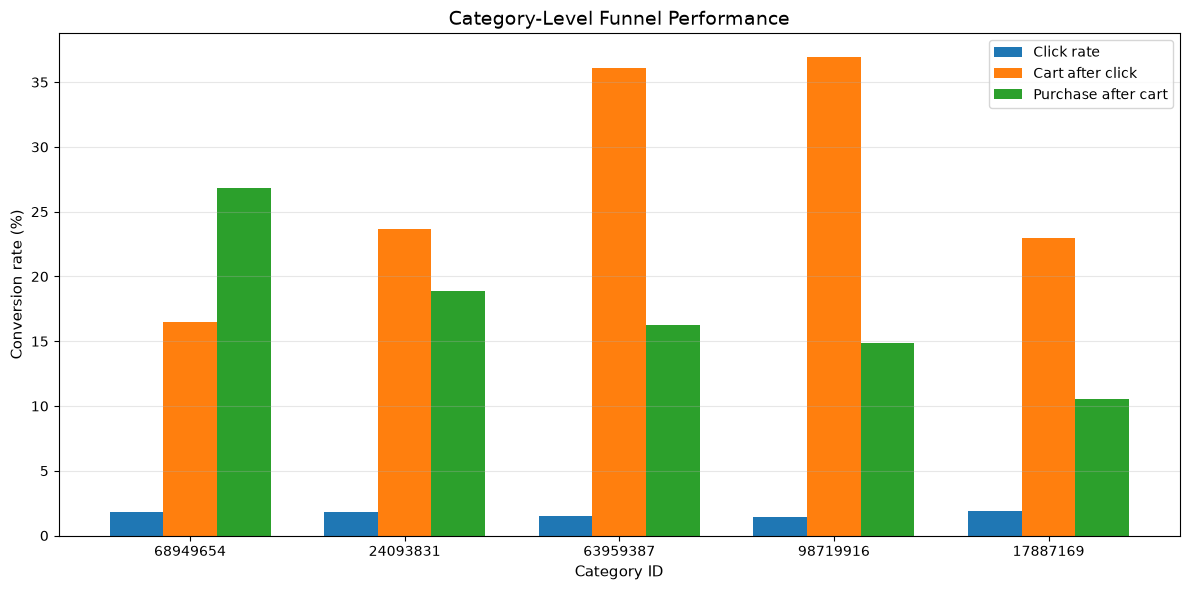

In [151]:
plot_df = category_funnel_chart_df.copy()

plot_df["category_id"] = plot_df["category_id"].astype(str)

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width,
    plot_df["click_rate_pct"],
    width,
    label="Click rate"
)

ax.bar(
    x,
    plot_df["cart_after_click_pct"],
    width,
    label="Cart after click"
)

ax.bar(
    x + width,
    plot_df["purchase_after_cart_pct"],
    width,
    label="Purchase after cart"
)

ax.set_title("Category-Level Funnel Performance")
ax.set_xlabel("Category ID")
ax.set_ylabel("Conversion rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["category_id"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "charts/category_funnel_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [144]:
product_coverage_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(
            CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS engaged_observations,

        MAX(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS had_purchase

    FROM product_search_stage

    WHERE category_id = 98719916

    GROUP BY category_id, product_id
)

SELECT
    CASE
        WHEN engaged_observations < 5 THEN '1–4'
        WHEN engaged_observations < 10 THEN '5–9'
        WHEN engaged_observations < 20 THEN '10–19'
        WHEN engaged_observations < 50 THEN '20–49'
        ELSE '50+'
    END AS engagement_bucket,

    COUNT(*) AS products,

    SUM(
        CASE WHEN had_purchase = 1 THEN 1 ELSE 0 END
    ) AS products_with_purchase,

    SUM(
        CASE WHEN had_purchase = 0 THEN 1 ELSE 0 END
    ) AS zero_purchase_products

FROM product_metrics

WHERE engaged_observations > 0

GROUP BY
    CASE
        WHEN engaged_observations < 5 THEN '1–4'
        WHEN engaged_observations < 10 THEN '5–9'
        WHEN engaged_observations < 20 THEN '10–19'
        WHEN engaged_observations < 50 THEN '20–49'
        ELSE '50+'
    END

ORDER BY
    CASE engagement_bucket
        WHEN '1–4' THEN 1
        WHEN '5–9' THEN 2
        WHEN '10–19' THEN 3
        WHEN '20–49' THEN 4
        WHEN '50+' THEN 5
    END;
""").df()

product_coverage_df

,engagement_bucket,products,products_with_purchase,zero_purchase_products
0,1–4,9491,552.0,8939.0
1,5–9,340,61.0,279.0
2,10–19,150,39.0,111.0
3,20–49,79,17.0,62.0
4,50+,34,21.0,13.0


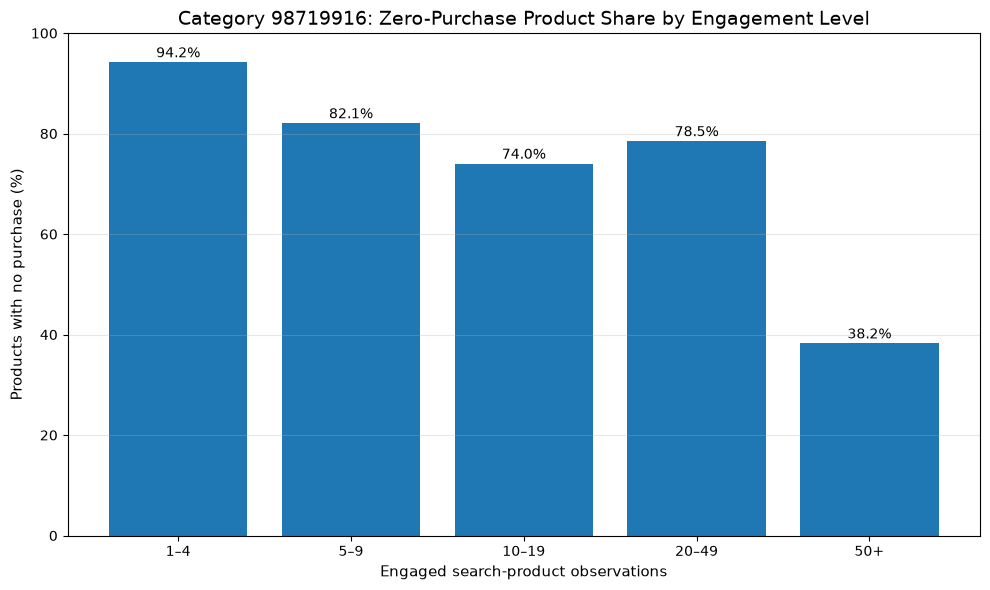

In [153]:
plot_df = product_coverage_df.copy()

plot_df["zero_purchase_pct"] = (
    100
    * plot_df["zero_purchase_products"]
    / plot_df["products"]
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    plot_df["engagement_bucket"],
    plot_df["zero_purchase_pct"]
)

ax.set_title(
    "Category 98719916: Zero-Purchase Product Share by Engagement Level"
)

ax.set_xlabel("Engaged search-product observations")
ax.set_ylabel("Products with no purchase (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["zero_purchase_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "charts/category_98719916_product_coverage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [146]:
sensitivity_chart_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(
            CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS engaged_observations,

        MAX(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS had_purchase

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
),

thresholds AS (
    SELECT 5 AS engagement_threshold
    UNION ALL
    SELECT 10
    UNION ALL
    SELECT 20
)

SELECT
    t.engagement_threshold,

    p.category_id,

    SUM(p.engaged_observations) AS total_engagement,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN p.had_purchase = 0
                THEN p.engaged_observations
                ELSE 0
            END
        ) / NULLIF(SUM(p.engaged_observations), 0),
        2
    ) AS zero_purchase_engagement_pct

FROM thresholds t
JOIN product_metrics p
    ON p.engaged_observations >= t.engagement_threshold

WHERE p.category_id IN (
    98719916,
    63959387,
    24093831,
    17887169,
    68949654
)

GROUP BY
    t.engagement_threshold,
    p.category_id

ORDER BY
    t.engagement_threshold,
    p.category_id;
""").df()

sensitivity_chart_df

,engagement_threshold,category_id,total_engagement,zero_purchase_engagement_pct
0,5,17887169,786.0,65.65
1,5,24093831,1054.0,62.14
2,5,63959387,6925.0,55.34
3,5,68949654,672.0,55.06
4,5,98719916,10438.0,59.89
5,10,17887169,233.0,38.63
6,10,24093831,294.0,58.50
7,10,63959387,3582.0,40.90
8,10,68949654,64.0,20.31
9,10,98719916,8266.0,54.19


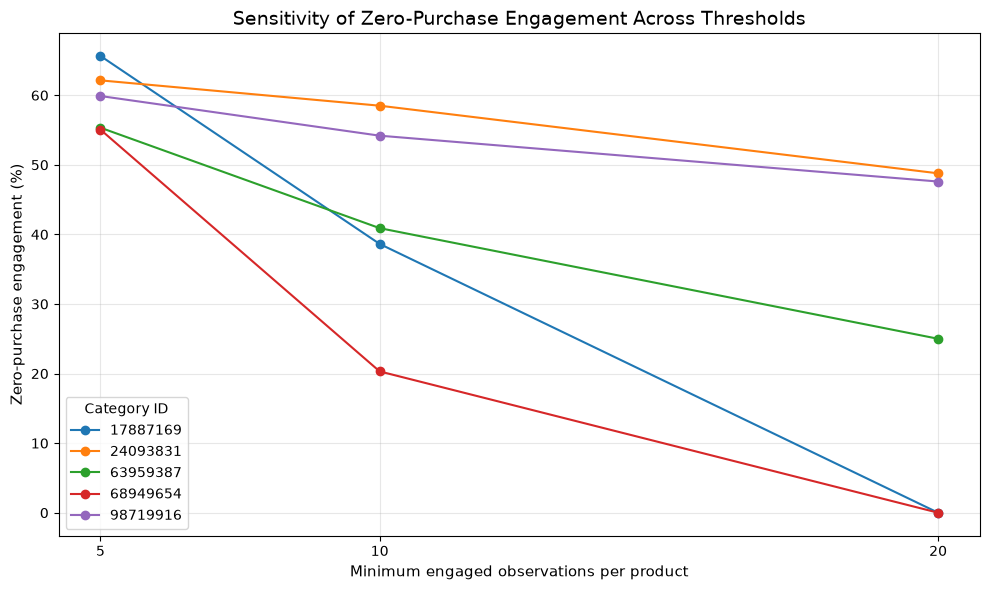

In [154]:
plot_df = sensitivity_chart_df.pivot(
    index="engagement_threshold",
    columns="category_id",
    values="zero_purchase_engagement_pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

for category in plot_df.columns:
    ax.plot(
        plot_df.index,
        plot_df[category],
        marker="o",
        label=str(category)
    )

ax.set_title(
    "Sensitivity of Zero-Purchase Engagement Across Thresholds"
)

ax.set_xlabel("Minimum engaged observations per product")
ax.set_ylabel("Zero-purchase engagement (%)")
ax.set_xticks([5, 10, 20])
ax.legend(title="Category ID")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "charts/zero_purchase_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

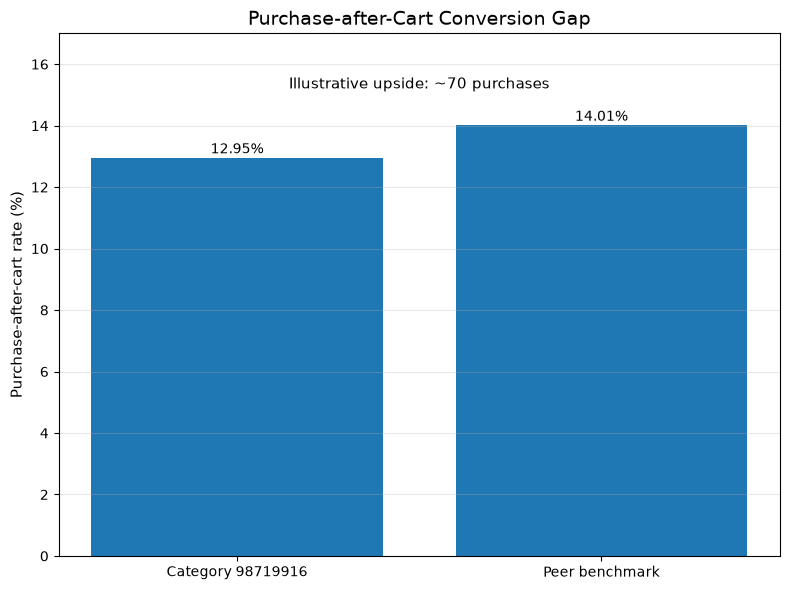

In [158]:
current_rate = 12.95
peer_rate = 14.01
incremental_purchases = 69.96

fig, ax = plt.subplots(figsize=(8, 6))

labels = [
    "Category 98719916",
    "Peer benchmark"
]

values = [
    current_rate,
    peer_rate
]

bars = ax.bar(labels, values)

ax.set_title("Purchase-after-Cart Conversion Gap")
ax.set_ylabel("Purchase-after-cart rate (%)")
ax.set_ylim(0, max(values) + 3)
ax.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

ax.text(
    0.5,
    max(values) + 1.2,
    f"Illustrative upside: ~{incremental_purchases:.0f} purchases",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.savefig(
    "charts/purchase_after_cart_opportunity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [160]:
import os

os.makedirs("charts", exist_ok=True)

In [162]:
import os

os.makedirs("dashboard_data", exist_ok=True)

In [163]:
con.sql("""
COPY (
    SELECT
        category_id,
        candidate_observations,
        clicks,
        carts,
        purchases,
        click_rate_pct,
        cart_after_click_pct,
        purchase_after_click_pct,
        purchase_after_cart_pct
    FROM category_funnel_performance
) TO 'dashboard_data/category_funnel.csv'
(HEADER, DELIMITER ',');
""")

In [164]:
con.sql("""
COPY (
    SELECT *
    FROM search_exploration_metrics
) TO 'dashboard_data/search_exploration.csv'
(HEADER, DELIMITER ',');
""")

In [165]:
con.sql("""
COPY (
    SELECT
        category_id,
        product_id,

        SUM(
            CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS engaged_observations,

        SUM(
            CASE
                WHEN final_stage IN ('cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS cart_observations,

        SUM(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS purchase_observations,

        MAX(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS had_purchase

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
) TO 'dashboard_data/product_metrics.csv'
(HEADER, DELIMITER ',');
""")

In [166]:
sensitivity_chart_df.to_csv(
    "dashboard_data/sensitivity_analysis.csv",
    index=False
)

In [167]:
purchase_opportunity_df.to_csv(
    "dashboard_data/purchase_opportunity.csv",
    index=False
)

In [168]:
dashboard_category_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,
    click_rate_pct,
    cart_after_click_pct,
    purchase_after_click_pct,
    purchase_after_cart_pct
FROM category_funnel_performance
WHERE category_id IN (
    98719916,
    63959387,
    24093831,
    17887169,
    68949654
)
""").df()

dashboard_category_df.to_csv(
    "dashboard_data/dashboard_category_summary.csv",
    index=False
)

In [169]:
dashboard_category_df["primary_bottleneck"] = np.select(
    [
        dashboard_category_df["cart_after_click_pct"] < 25,
        dashboard_category_df["purchase_after_cart_pct"] < 10
    ],
    [
        "Click-to-cart bottleneck",
        "Post-cart bottleneck"
    ],
    default="Relatively balanced funnel"
)

dashboard_category_df.to_csv(
    "dashboard_data/dashboard_category_summary.csv",
    index=False
)

dashboard_category_df

,category_id,candidate_observations,clicks,carts,purchases,click_rate_pct,cart_after_click_pct,purchase_after_click_pct,purchase_after_cart_pct,primary_bottleneck
0,68949654,953096,17601.0,2903.0,780.0,1.847,16.493,4.432,26.869,Click-to-cart bottleneck
1,98719916,1071768,15560.0,5748.0,855.0,1.452,36.941,5.495,14.875,Relatively balanced funnel
2,63959387,1252530,19329.0,6983.0,1135.0,1.543,36.127,5.872,16.254,Relatively balanced funnel
3,24093831,814752,14837.0,3511.0,663.0,1.821,23.664,4.469,18.884,Click-to-cart bottleneck
4,17887169,356564,6712.0,1544.0,163.0,1.882,23.004,2.428,10.557,Click-to-cart bottleneck


In [170]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nDashboard folder exists:")
print(os.path.exists("dashboard_data"))

if os.path.exists("dashboard_data"):
    print("\nFiles inside dashboard_data:")
    print(os.listdir("dashboard_data"))

Current working directory:
C:\Users\amodk

Dashboard folder exists:
True

Files inside dashboard_data:
['category_funnel.csv', 'dashboard_category_summary.csv', 'product_metrics.csv', 'purchase_opportunity.csv', 'search_exploration.csv', 'sensitivity_analysis.csv']


In [171]:
import os
import pandas as pd

os.makedirs("dashboard_data", exist_ok=True)

# 1. Category summary
dashboard_category_df = con.sql("""
SELECT
    category_id,
    candidate_observations,
    clicks,
    carts,
    purchases,
    click_rate_pct,
    cart_after_click_pct,
    purchase_after_click_pct,
    purchase_after_cart_pct
FROM category_funnel_performance
WHERE category_id IN (
    98719916,
    63959387,
    24093831,
    17887169,
    68949654
)
ORDER BY category_id
""").df()

dashboard_category_df.to_csv(
    "dashboard_data/dashboard_category_summary.csv",
    index=False
)


# 2. Search exploration
search_exploration_df = con.sql("""
SELECT *
FROM search_exploration_metrics
""").df()

search_exploration_df.to_csv(
    "dashboard_data/search_exploration.csv",
    index=False
)


# 3. Product metrics
product_metrics_df = con.sql("""
SELECT
    category_id,
    product_id,

    SUM(
        CASE
            WHEN final_stage IN ('click', 'cart', 'purchase')
            THEN 1 ELSE 0
        END
    ) AS engaged_observations,

    SUM(
        CASE
            WHEN final_stage IN ('cart', 'purchase')
            THEN 1 ELSE 0
        END
    ) AS cart_observations,

    SUM(
        CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END
    ) AS purchase_observations,

    MAX(
        CASE
            WHEN final_stage = 'purchase'
            THEN 1 ELSE 0
        END
    ) AS had_purchase

FROM product_search_stage

GROUP BY
    category_id,
    product_id
""").df()

product_metrics_df.to_csv(
    "dashboard_data/product_metrics.csv",
    index=False
)


# 4. Sensitivity analysis
sensitivity_df = con.sql("""
WITH product_metrics AS (
    SELECT
        category_id,
        product_id,

        SUM(
            CASE
                WHEN final_stage IN ('click', 'cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS engaged_observations,

        MAX(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS had_purchase

    FROM product_search_stage

    GROUP BY
        category_id,
        product_id
),

thresholds AS (
    SELECT 5 AS engagement_threshold
    UNION ALL
    SELECT 10
    UNION ALL
    SELECT 20
)

SELECT
    t.engagement_threshold,
    p.category_id,
    SUM(p.engaged_observations) AS total_engagement,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN p.had_purchase = 0
                THEN p.engaged_observations
                ELSE 0
            END
        ) / NULLIF(SUM(p.engaged_observations), 0),
        2
    ) AS zero_purchase_engagement_pct

FROM thresholds t
JOIN product_metrics p
    ON p.engaged_observations >= t.engagement_threshold

WHERE p.category_id IN (
    98719916,
    63959387,
    24093831,
    17887169,
    68949654
)

GROUP BY
    t.engagement_threshold,
    p.category_id

ORDER BY
    t.engagement_threshold,
    p.category_id
""").df()

sensitivity_df.to_csv(
    "dashboard_data/sensitivity_analysis.csv",
    index=False
)


# 5. Purchase opportunity
purchase_opportunity_df = con.sql("""
WITH category_metrics AS (
    SELECT
        category_id,

        SUM(
            CASE
                WHEN final_stage IN ('cart', 'purchase')
                THEN 1 ELSE 0
            END
        ) AS cart_observations,

        SUM(
            CASE
                WHEN final_stage = 'purchase'
                THEN 1 ELSE 0
            END
        ) AS purchase_observations

    FROM product_search_stage

    WHERE category_id IN (
        98719916,
        63959387,
        24093831,
        17887169,
        68949654
    )

    GROUP BY category_id
),

benchmark AS (
    SELECT
        SUM(purchase_observations) * 1.0
        / NULLIF(SUM(cart_observations), 0)
        AS benchmark_purchase_after_cart_rate

    FROM category_metrics

    WHERE category_id IN (
        63959387,
        24093831,
        17887169
    )
)

SELECT
    c.category_id,
    c.cart_observations,
    c.purchase_observations,

    ROUND(
        100.0 * c.purchase_observations
        / NULLIF(c.cart_observations, 0),
        2
    ) AS current_purchase_after_cart_pct,

    ROUND(
        100.0 * b.benchmark_purchase_after_cart_rate,
        2
    ) AS peer_benchmark_purchase_after_cart_pct,

    ROUND(
        c.cart_observations
        * b.benchmark_purchase_after_cart_rate
        - c.purchase_observations,
        2
    ) AS illustrative_incremental_purchases

FROM category_metrics c
CROSS JOIN benchmark b

WHERE c.category_id = 98719916
""").df()

purchase_opportunity_df.to_csv(
    "dashboard_data/purchase_opportunity.csv",
    index=False
)


print("Export completed successfully.")

Export completed successfully.


In [172]:
expected_files = [
    "dashboard_category_summary.csv",
    "search_exploration.csv",
    "product_metrics.csv",
    "sensitivity_analysis.csv",
    "purchase_opportunity.csv"
]

for filename in expected_files:
    filepath = os.path.join("dashboard_data", filename)

    print(
        f"{filename}: "
        f"{'SAVED' if os.path.exists(filepath) else 'MISSING'}"
    )

dashboard_category_summary.csv: SAVED
search_exploration.csv: SAVED
product_metrics.csv: SAVED
sensitivity_analysis.csv: SAVED
purchase_opportunity.csv: SAVED


In [173]:
print(os.path.abspath("dashboard_data"))

C:\Users\amodk\dashboard_data
